In [1]:
try:
    import xgboost as xgb
    import lightgbm as lgb
    import catboost as cgb
    import shap
except:
    !pip install -qq xgboost lightgbm catboost shap
    import xgboost as xgb
    import lightgbm as lgb
    import catboost as cgb
    import shap

In [2]:
# !pip install -qq -U hvplot
# import hvplot.pandas
# hvplot.extension('matplotlib')

## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    get_ipython().run_line_magic('load_ext', 'cuml.accel')
    from cuml.preprocessing import TargetEncoder as cuTE
else:
    pass

ℹ️ Running on Cuda: False


In [3]:
## -- System dependencies --
import sys, os, gc

## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- Machine Learning --
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, PredictionErrorDisplay

import warnings

In [4]:
print(f"xgboost  version: {xgb.__version__}")
print(f"lightgbm version: {lgb.__version__}")
print(f"catboost version: {cgb.__version__}")

xgboost  version: 3.1.3
lightgbm version: 4.6.0
catboost version: 1.2.8


In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
plt.style.use('ggplot')
# sns.set_style("whitegrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'orange']

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

In [6]:
### Load Data ###
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv", index_col='id')
test = pd.read_csv(PATH+"test.csv", index_col='id')

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

ORIG_PATH = '/kaggle/input/exam-score-prediction-dataset/'
orig = pd.read_csv(ORIG_PATH+'Exam_Score_Prediction.csv', index_col='student_id')

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 12)
Test shape: (270000, 11)
Original shape: (20000, 12)

Total Numerical: 4
Total Categorical: 7
Total base features: 11


In [7]:
# ## -- Check if id is unique --
# print(f"Train ID column is Unique: {train.id.is_unique}")
# print(f"Test ID column is Unique: {test.id.is_unique}")

In [8]:
display(train.head())
train.info()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 62.5+ MB


In [9]:
train.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [10]:
train.describe(exclude='number').T

,count,unique,top,freq
gender,630000,3,other,211097
course,630000,7,b.tech,131236
internet_access,630000,2,yes,579423
sleep_quality,630000,3,poor,213675
study_method,630000,5,coaching,131697
facility_rating,630000,3,medium,214082
exam_difficulty,630000,3,moderate,353982


In [11]:
display(test.head())
test.info()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
id,,,,,,,,,,,
630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


<class 'pandas.core.frame.DataFrame'>
Index: 270000 entries, 630000 to 899999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               270000 non-null  int64  
 1   gender            270000 non-null  object 
 2   course            270000 non-null  object 
 3   study_hours       270000 non-null  float64
 4   class_attendance  270000 non-null  float64
 5   internet_access   270000 non-null  object 
 6   sleep_hours       270000 non-null  float64
 7   sleep_quality     270000 non-null  object 
 8   study_method      270000 non-null  object 
 9   facility_rating   270000 non-null  object 
 10  exam_difficulty   270000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 24.7+ MB


In [12]:
orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 20001
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 2.0+ MB


In [13]:
# Check if column names are the same regardless of order
are_same_set = set(train.columns) == set(orig.columns)
print(f"Are column names the same regardless of order (train vs orig)? {are_same_set}")

# Check if column names are the same and in the same order
are_same_exact = train.columns.equals(orig.columns)
print(f"Are column names exactly the same and in the same order (train vs orig)? {are_same_exact}")

Are column names the same regardless of order (train vs orig)? True
Are column names exactly the same and in the same order (train vs orig)? True


In [14]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='bone')

,age,study_hours,class_attendance,sleep_hours,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
Train,8,792,617,66,3,7,2,3,5,3,3
Original,8,784,589,59,3,7,2,3,5,3,3
Test,8,786,604,64,3,7,2,3,5,3,3


### YDATA-PROFILE REPORT

In [15]:
# # %%capture
# ## -- Comprehensive EDA --
# !{sys.executable} -m pip install -qq -U ydata-profiling[notebook]
# !pip install -qq jupyter-contrib-nbextensions
# !jupyter nbextension enable --py widgetsnbextension

In [16]:
# from ydata_profiling import ProfileReport, compare

# ## -- Single EDA --
# # profile_df = ProfileReport(train, title="Insights into TARGET Types", explorative=True)
# # profile_df.to_notebook_iframe()

# # profile_df.to_file("Loan_EDA_Report.html")

# ## -- Create Profiles for Datasets --
# train_report = ProfileReport(train, title="Train", explorative=True)
# # test_report = ProfileReport(test, title="Test", explorative=True)
# orig_report = ProfileReport(orig, title="Original", explorative=True)

# ## -- Compare 2++ Datasets --
# comparison_report = compare([train_report, test_report])

# # ## -- Obtain merged statistics (Don't know its purpose yet)
# # statistics = comparison_report.get_description()
# ## -- Save report to file
# comparison_report.to_file("Student Test Scores | Train-Orig_Stats.html")
# comparison_report.to_notebook_iframe()

# EDA

## ~ NUMERIC

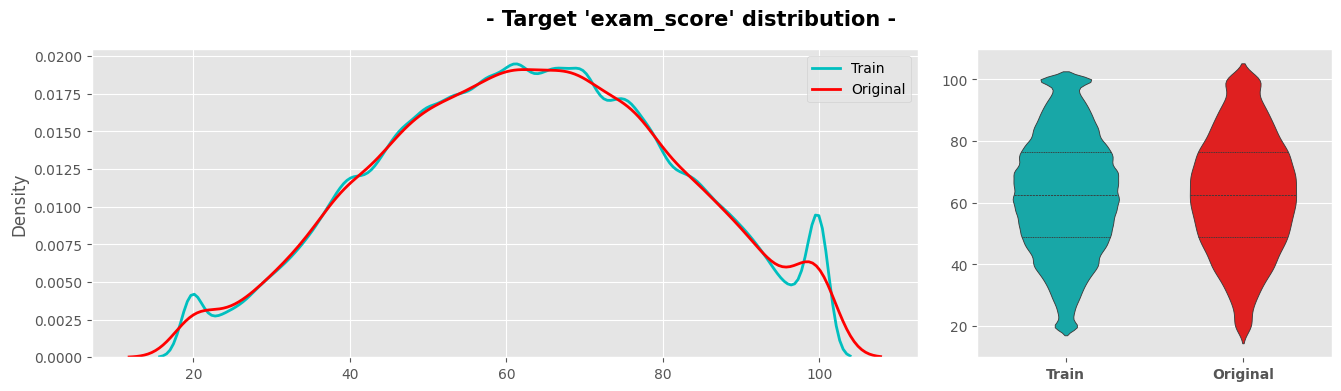

In [17]:
## -- Plot TARGET distribution --
# plt.figure(figsize=(16, 6))
_, axs = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios':[0.7, 0.3], 'wspace':0.1})

## -- KDEs --
sns.kdeplot(data=train, x=TARGET, color=PALETTE[0], linewidth=2, ax=axs[0], label='Train')
sns.kdeplot(data=orig, x=TARGET, color=PALETTE[1], linewidth=2, ax=axs[0], label='Original')
axs[0].legend()
axs[0].set_xlabel('')

# Boxplots
# pd.concat([train[[TARGET]], orig[[TARGET]]], axis=1).boxplot(
#     widths=0.6,
#     showmeans=True,
#     # meanline=True,
#     # patch_artist=True,
#     # notch=True,
#     # labels=['Train', 'Original'],
#     ax=axs[1])

sns.violinplot(
    data=[train[TARGET].values, orig[TARGET].values],
    inner='quart',
    width=0.6,
    # size=1,
    # width=0.6,
    # linewidth=2,
    # fliersize=.1,
    ax=axs[1],
    palette=PALETTE)

axs[1].set_xticklabels(['Train', 'Original'], fontdict={'weight': 'bold'})

plt.suptitle(f"- Target '{TARGET}' distribution -", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
def distplots_data(train: pd.DataFrame, test: pd.DataFrame, orig: pd.DataFrame, features: list[str]):
    # 1) Concatenate data
    df = pd.concat([
            train[features].assign(Source='Train'),
            test[features].assign(Source='Test'),
            orig[features].assign(Source='Original')
    ], ignore_index=True)
    
    for i, col in enumerate(features):
        _, axs = plt.subplots(1, 2, figsize=(16, 4),
            gridspec_kw={'hspace': 0.3, 'wspace': 0.15, 'width_ratios': [0.7, 0.3]}
            )
        ## -- KDE plots --
        sns.kdeplot(data=train, x=col, color=PALETTE[0], linewidth=2, ax=axs[0], label='Train')
        sns.kdeplot(data=test, x=col, color=PALETTE[1], linewidth=2, ax=axs[0], label='Test')
        sns.kdeplot(data=orig, x=col, color=PALETTE[2], linewidth=2, ax=axs[0], label='Orig')
        axs[0].set_title(f'\n{col}', fontdict={'size': 15, 'weight': 'bold'})
        axs[0].set(xlabel='')
        axs[0].legend()
        
        ## -- BOX plots --
        sns.boxplot(
            data=df,
            y=col,
            x='Source',
            width=0.5,
            linewidth=2,
            ax=axs[1],
            palette=PALETTE
        )
        axs[1].set(xlabel='')
        axs[1].tick_params(axis='both', which='major')
        axs[1].set_xticklabels(['Train', 'Test', 'Original'], fontweight='semibold')

    plt.tight_layout()
    plt.show()

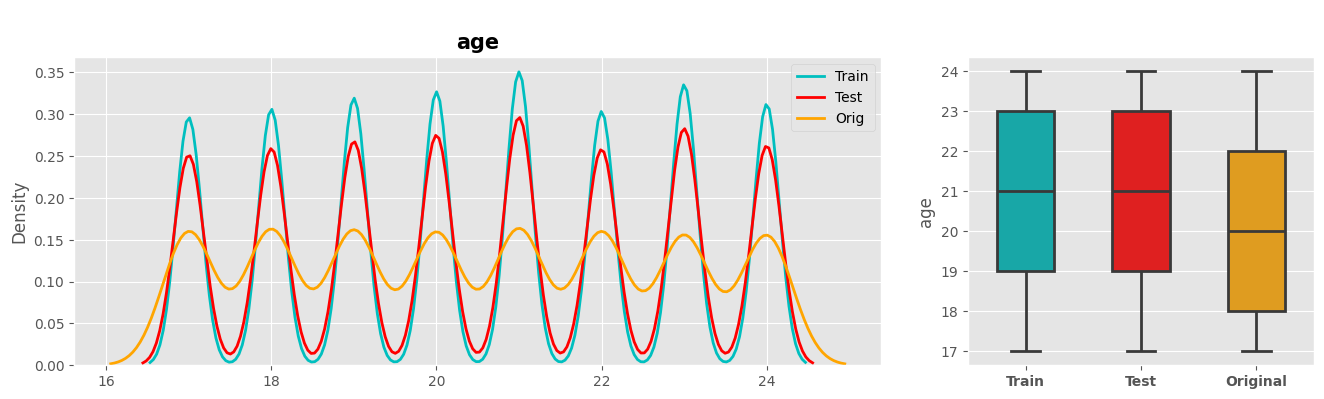

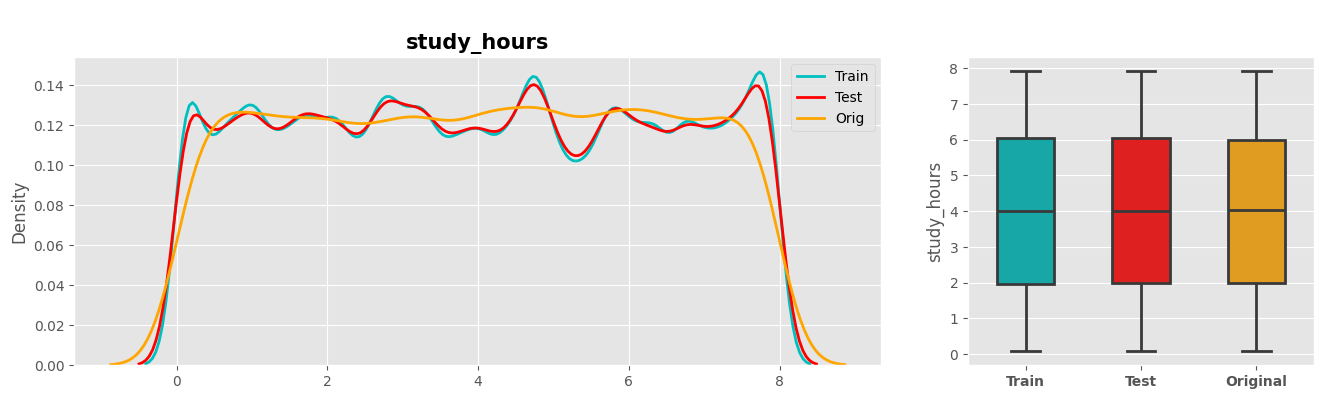

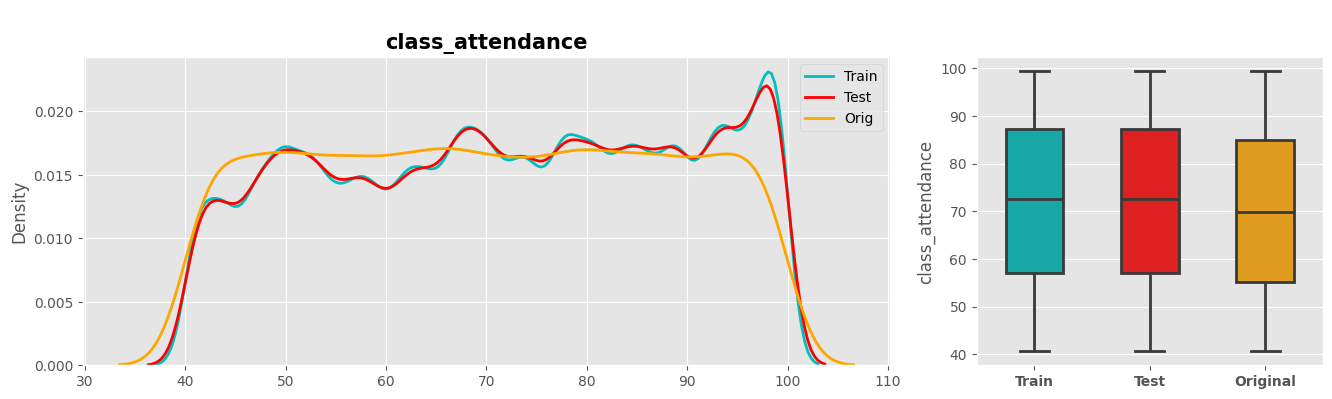

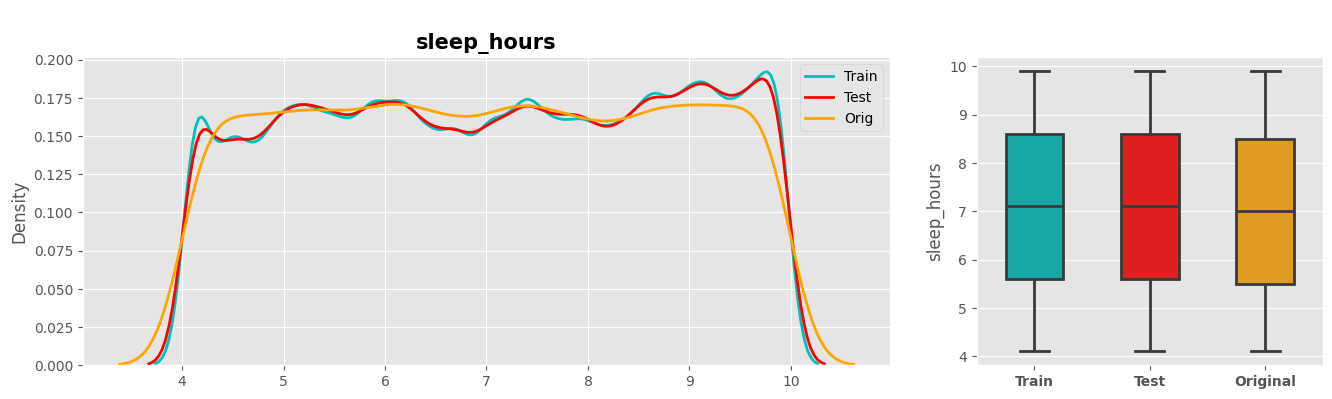

In [19]:
distplots_data(train, test, orig, NUMS) # Plot floats

## ~ CATEGORICAL

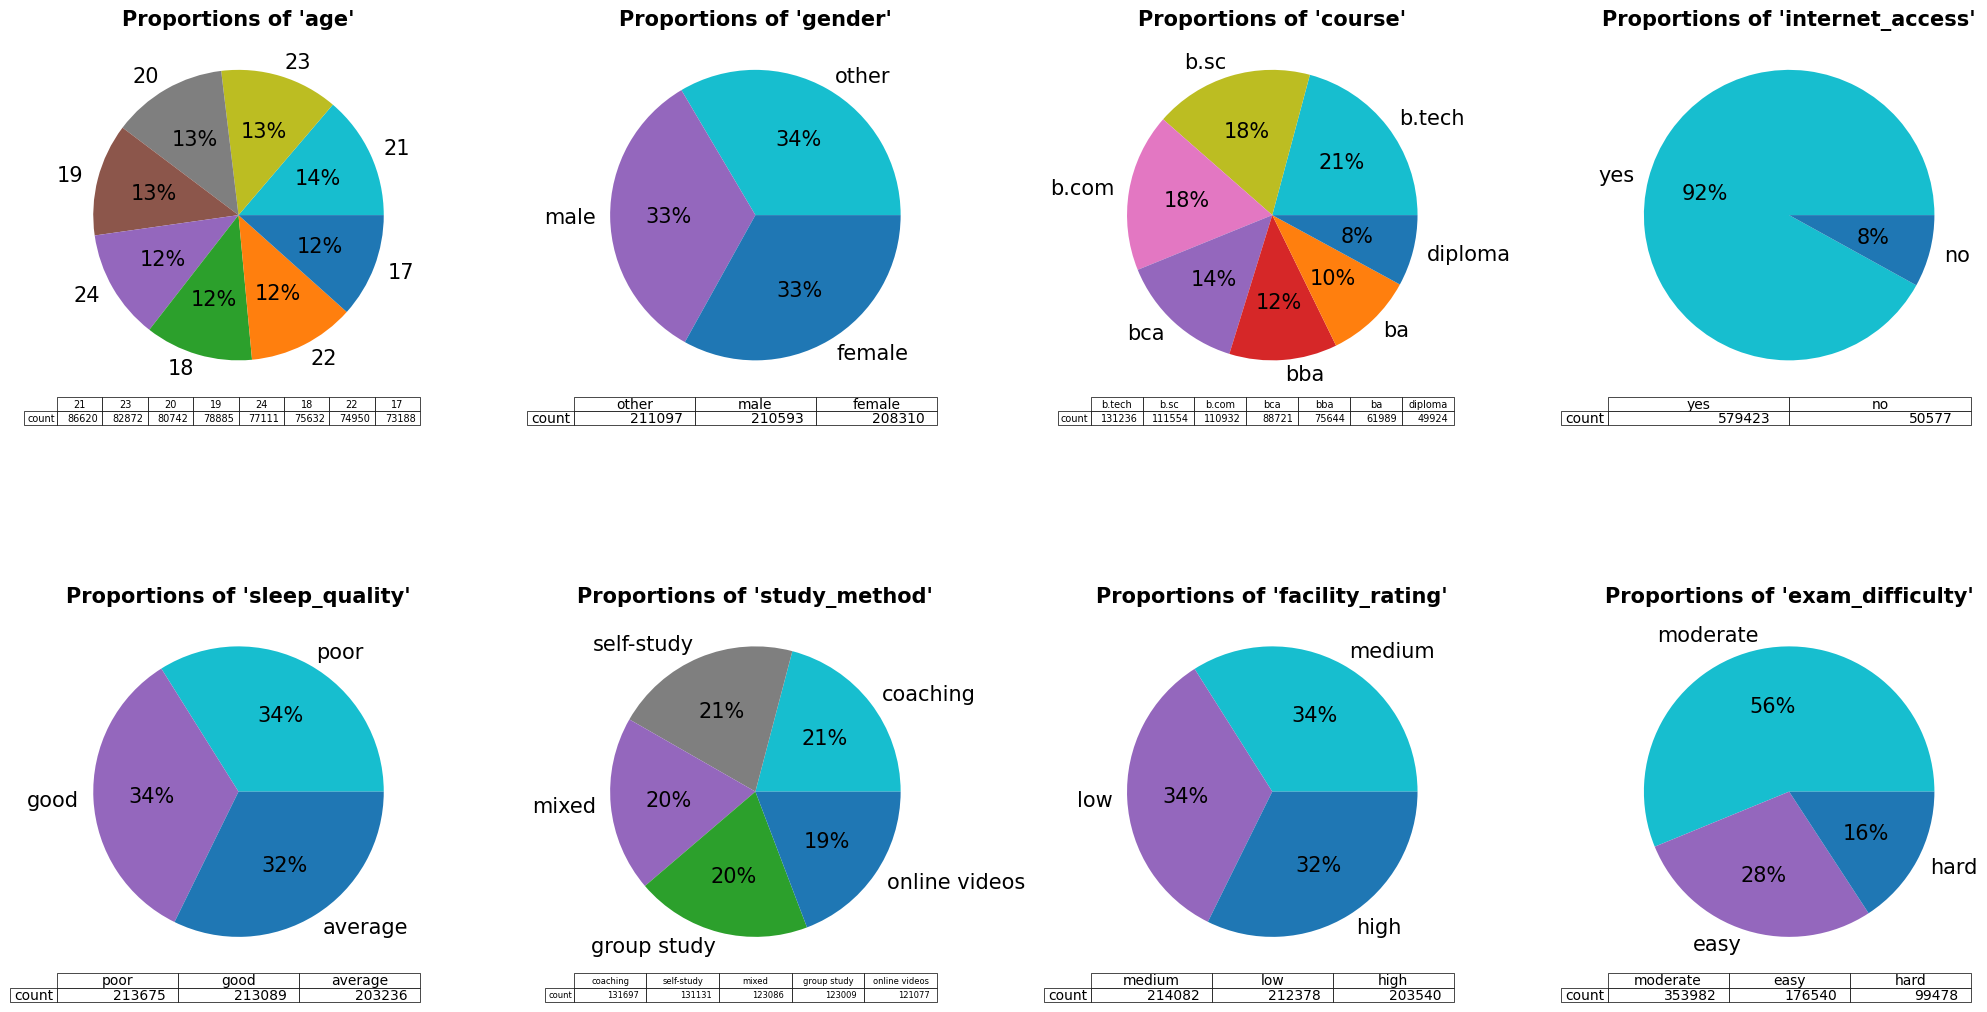

In [20]:
## -- Categorical Features --
plt.figure(figsize=(20, 12))
for i, col in enumerate(['age']+CATS):
    plt.subplot(2, 4, i+1)
    values=train[col].value_counts(dropna=False)
    values.plot.pie(autopct='%1.0f%%', fontsize=15, table=True, cmap='tab10_r')
    plt.title(f"Proportions of '{col}'", fontdict={'size':15, 'weight': 'bold'})
    plt.axis('off')

plt.tight_layout()
plt.show()

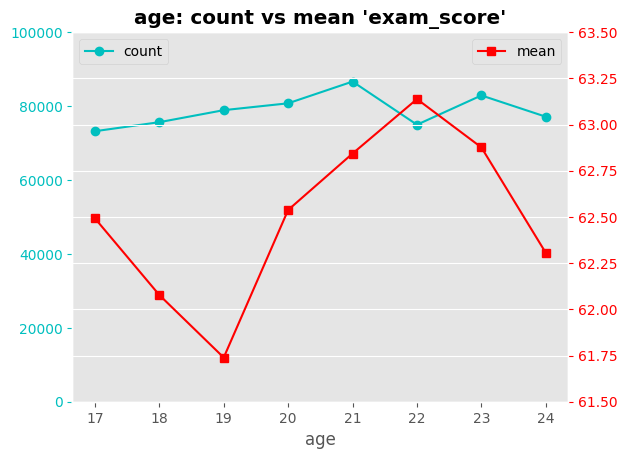

In [21]:
ax = train.groupby(['age']).size().plot.line(marker='o', color='c', label='count')
ax.tick_params(axis='y', color='c', labelcolor='c')
ax.axis(ymin=0, ymax=100_000)
ax.legend(loc='upper left')
ax.grid()

ax2 = ax.twinx()
train.groupby(['age'])[TARGET].mean().plot.line(marker='s', color='r', ax=ax2, label='mean')
ax2.tick_params(axis='y', color='r', labelcolor='r')
ax2.axis(ymin=61.5, ymax=63.5)
ax2.legend(loc='upper right')

plt.title(f"age: count vs mean '{TARGET}'", fontweight='bold')
plt.show()

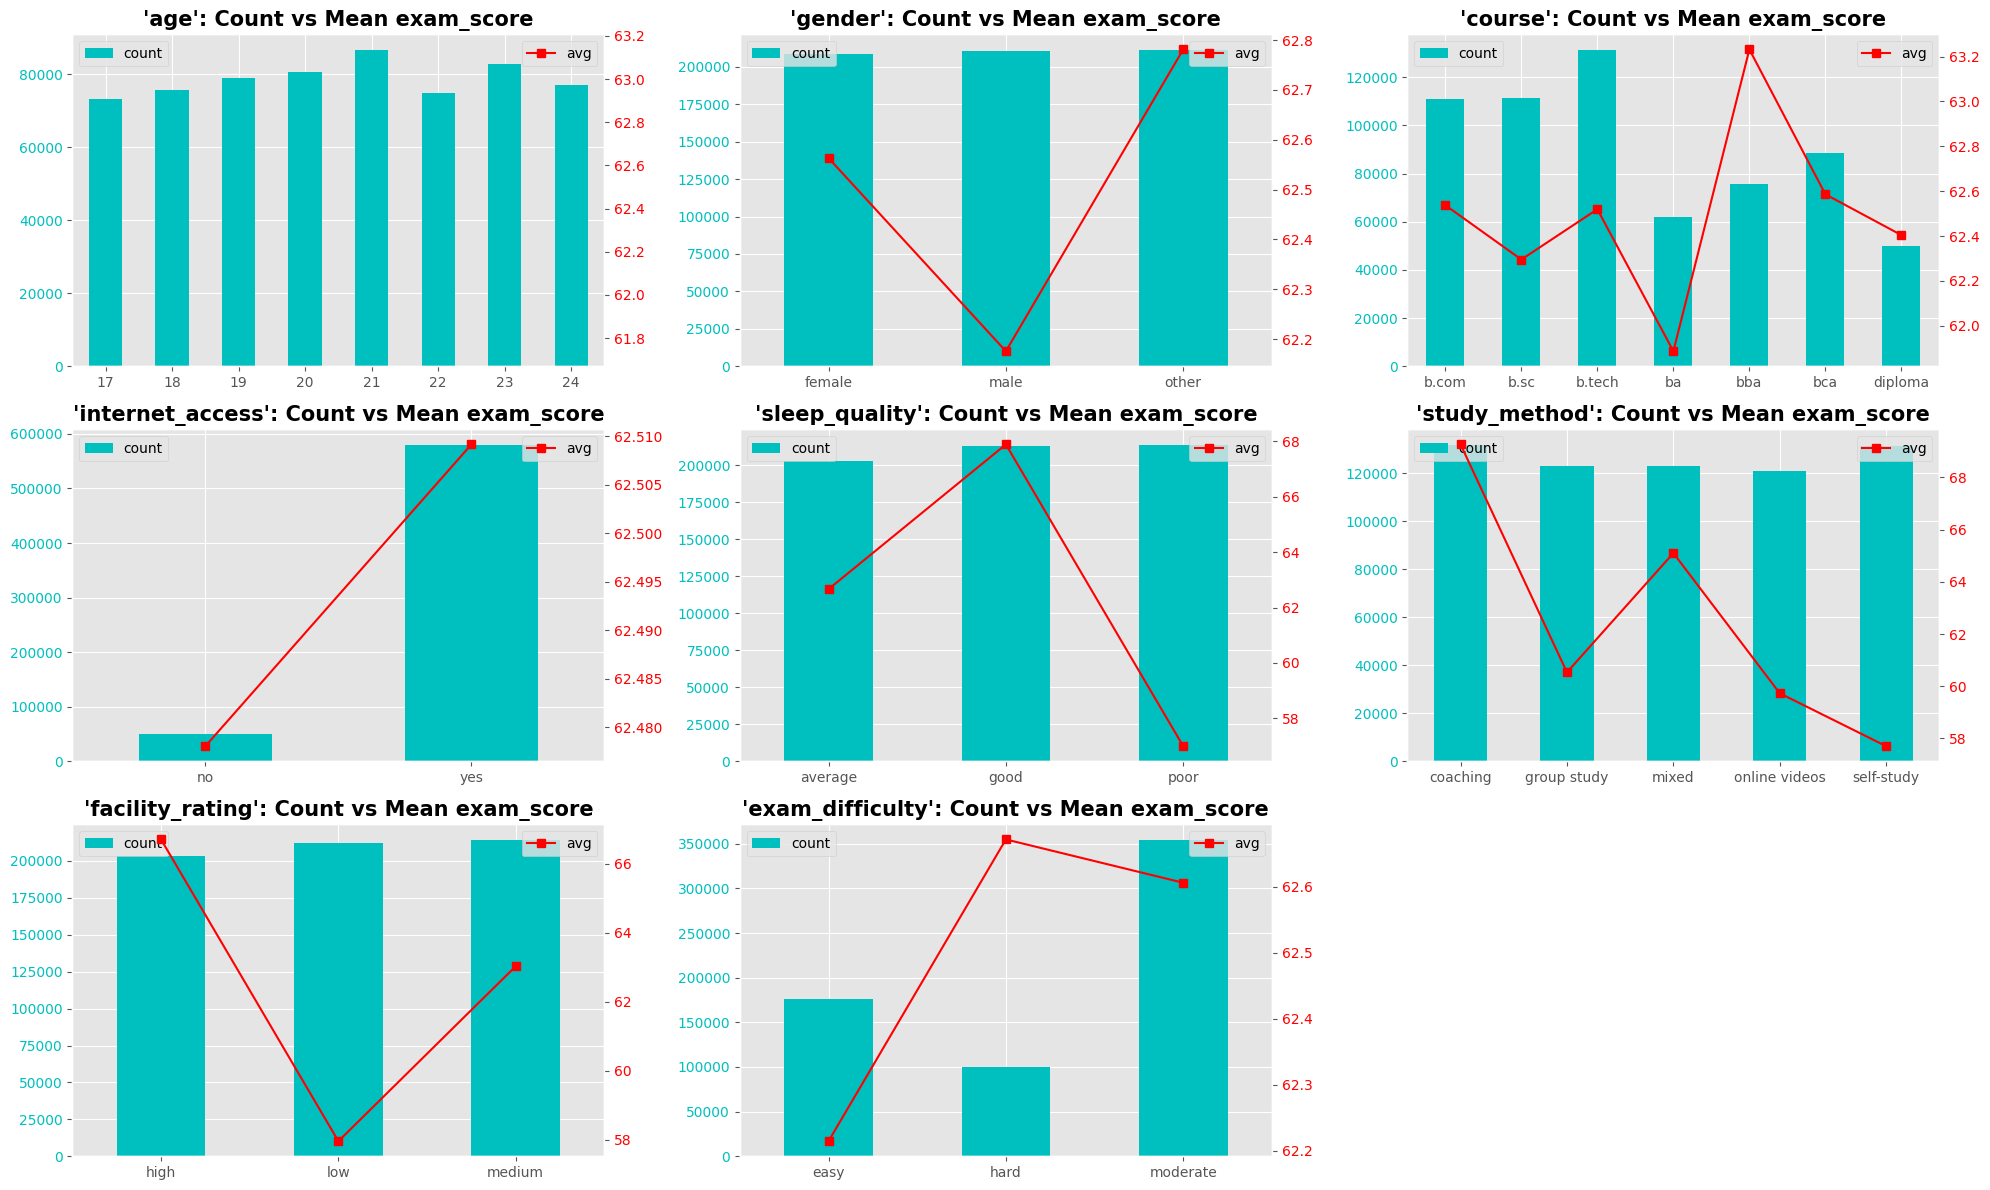

In [22]:
## -- Explore counts & target means of categories --
palette = ['r', 'g', 'y', 'c', 'm', 'brown', 'peru', 'orange', 'olive']

for i, c in enumerate(['age']+CATS):
    plt.subplot(3, 3, i+1)
    c1 = 'c'
    count_cats = train.groupby([c]).size()
    ax = count_cats.plot.bar(color=c1, figsize=(20, 12), label='count')
    ax.set_xlabel('')
    ax.set_title(f"{c!r}: Count vs Mean {TARGET}", fontdict={'size':15, 'weight':'bold'})
    # ax.axis(ymin=0, ymax=90000)
    ax.tick_params(axis='y', labelcolor=c1)
    ax.legend(loc='upper left')
    plt.xticks(rotation=0)
    
    c2 = 'r'
    ax2 = ax.twinx()
    avg_cats = train.groupby([c])[TARGET].mean()
    avg_cats.plot.line(marker='s', color=c2, ax=ax2, label='avg')
    ax2.tick_params(axis='y', labelcolor=c2)
    ax2.legend(loc='upper right')
    
    plt.legend()
    plt.grid()
    
plt.tight_layout()
plt.show()
#--> Most category features have ordinal properties, e.g., low=0, medium=1, high=2

In [23]:
# ## -- Simple drift check --
# train['class_attendance'].rolling(10).mean().plot(figsize=(20, 5), alpha=0.5, label='train')
# orig['class_attendance'].rolling(10).mean().plot(alpha=0.75, label='orig')
# test['class_attendance'].rolling(10).mean().plot(alpha=0.75, label='test')
# plt.legend(); plt.show()

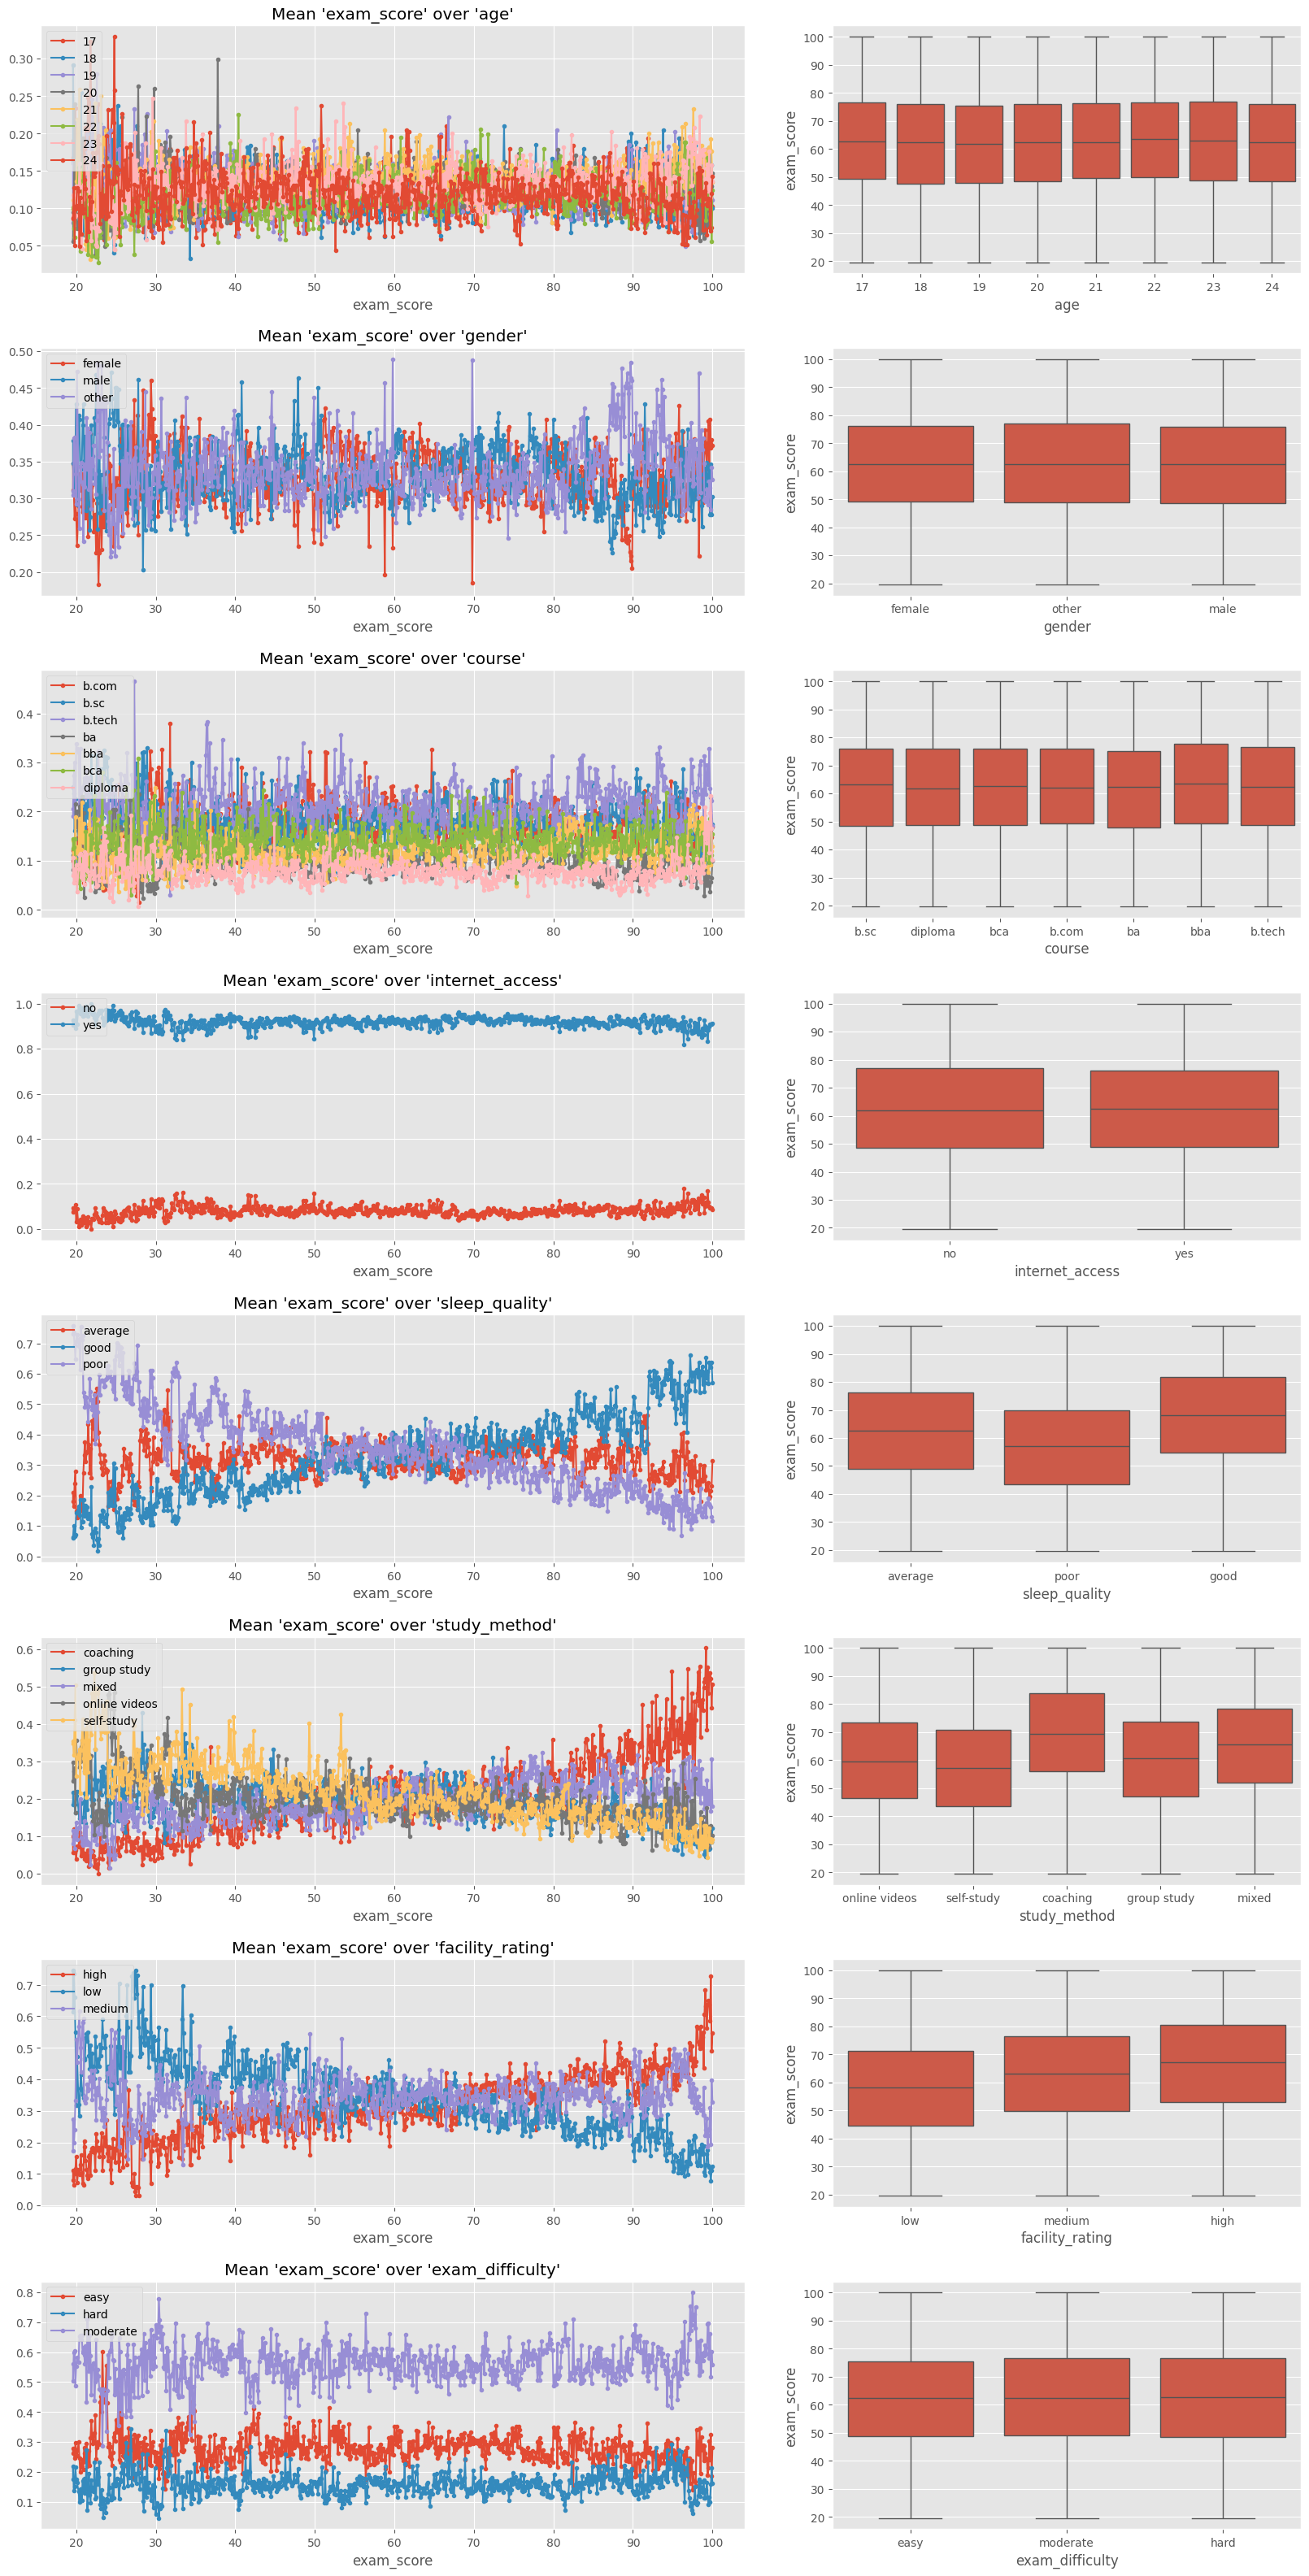

In [24]:
## -- Value counts of category by target --
N_CATS = len(['age']+CATS)

## -- Create a grid: one row per feature, two columns (KDE vs Boxplot)
fig, axs = plt.subplots(
        N_CATS, 2, figsize=(20, max(5, N_CATS * 5)),
        gridspec_kw={'hspace':0.3, 'wspace':0.15, 'width_ratios':[0.6, 0.4]}
    )
## -- Ensure axs is always 2D for consistent indexing
if N_CATS == 1:
    axs = axs.reshape(1, 2)

for i, col in enumerate(['age']+CATS):
    tmp = (
        train.groupby(TARGET)[col]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )
    ax1 = axs[i, 0]
    # sns.lineplot(tmp, ax=ax1, markers=True, palette='Set1')
    tmp.plot(ax=ax1, marker='.', #colormap='Set1',
             title=f"Mean '{TARGET}' over '{col}'")
    ax1.legend(loc='upper left')

    ax2 = axs[i, 1] # Plot 2
    # train.boxplot(TARGET, col, showmeans=True, ax=ax2)
    sns.boxplot(train, x=col, y=TARGET, ax=ax2) # 
    ax2.tick_params(axis='both', which='major')

plt.tight_layout()
plt.show()

In [25]:
## -- Factorize using combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c], orig[c]])
    combined = combined.factorize()[0]
    train[c] = combined[:len(train)]
    test[c]  = combined[len(train):len(train)+len(test)]
    orig[c]  = combined[-len(orig):]

print('Label encoding complete!')

## -- Treat age(8 unique values) as category --
NUMS.remove('age')
CATS.append('age')

train.shape, test.shape, orig.shape

Label encoding complete!


((630000, 12), (270000, 11), (20000, 12))

In [26]:
# ordinal_maps = {
#     "gender": {"male":0, "female":1, "other":2},
#     "internet_access": {"no":0, "yes":1},
#     "sleep_quality": {"poor":0, "average":1, "good":2},
#     "facility_rating": {"low":0, "medium":1, "high":2},
#     "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
#     "course":{"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#     "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
# }

# for c in CATS:
#         train[c] = train[c].map(ordinal_maps[c]).fillna(-1).astype('int32')
#         test[c]  = test[c].map(ordinal_maps[c]).fillna(-1).astype('int32')
#         orig[c]  = orig[c].map(ordinal_maps[c]).fillna(-1).astype('int32')

In [27]:
train.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,0,0,7.91,98.8,0,4.9,0,0,0,0,78.3
1,18,1,1,4.95,94.8,1,4.7,1,1,1,1,46.7
2,20,0,0,4.68,92.6,1,5.8,1,2,2,1,99.0
3,19,2,0,2.00,49.5,1,8.3,0,3,2,1,63.9
4,23,2,2,7.65,86.9,1,9.6,2,1,2,0,100.0


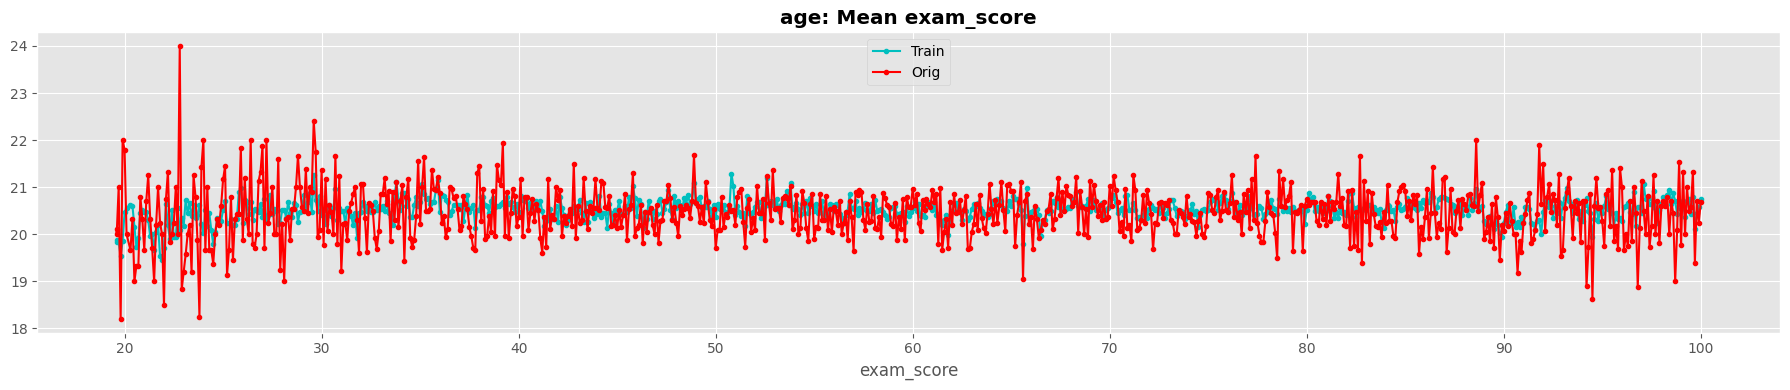

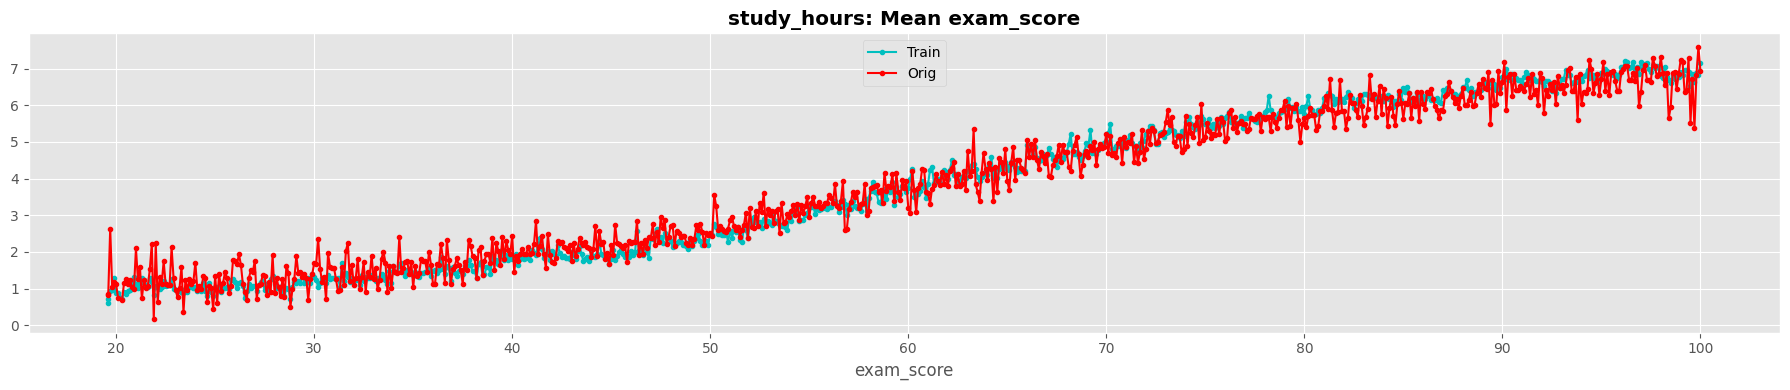

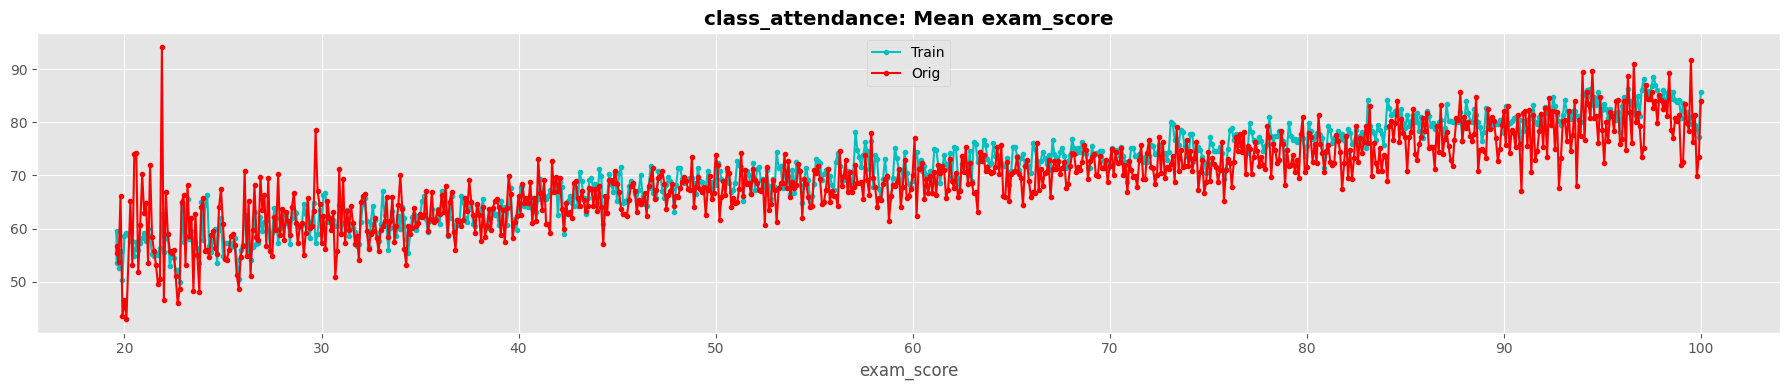

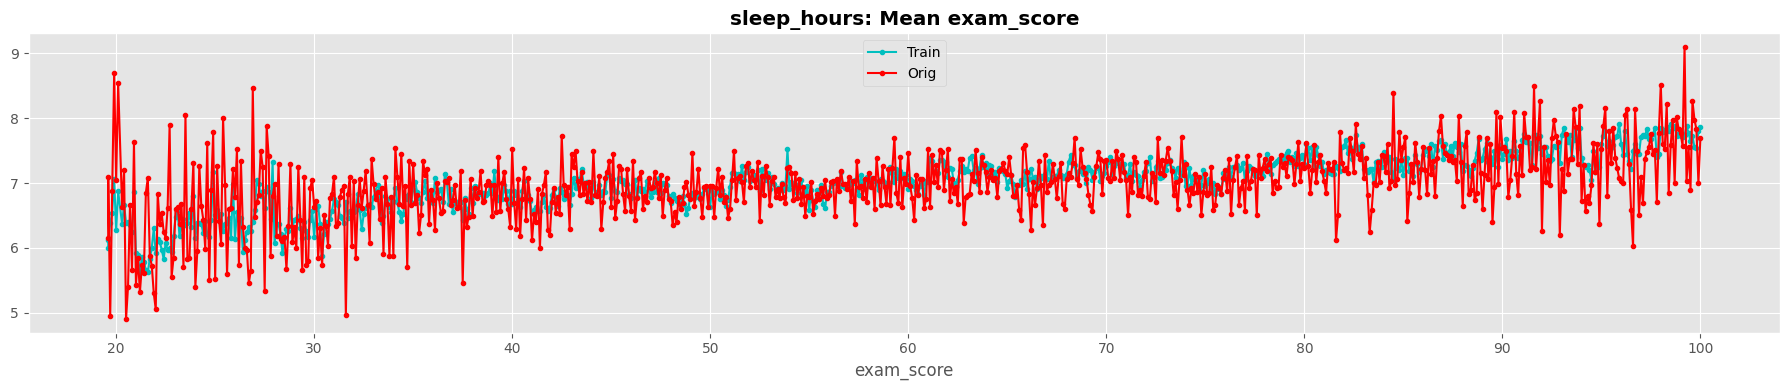

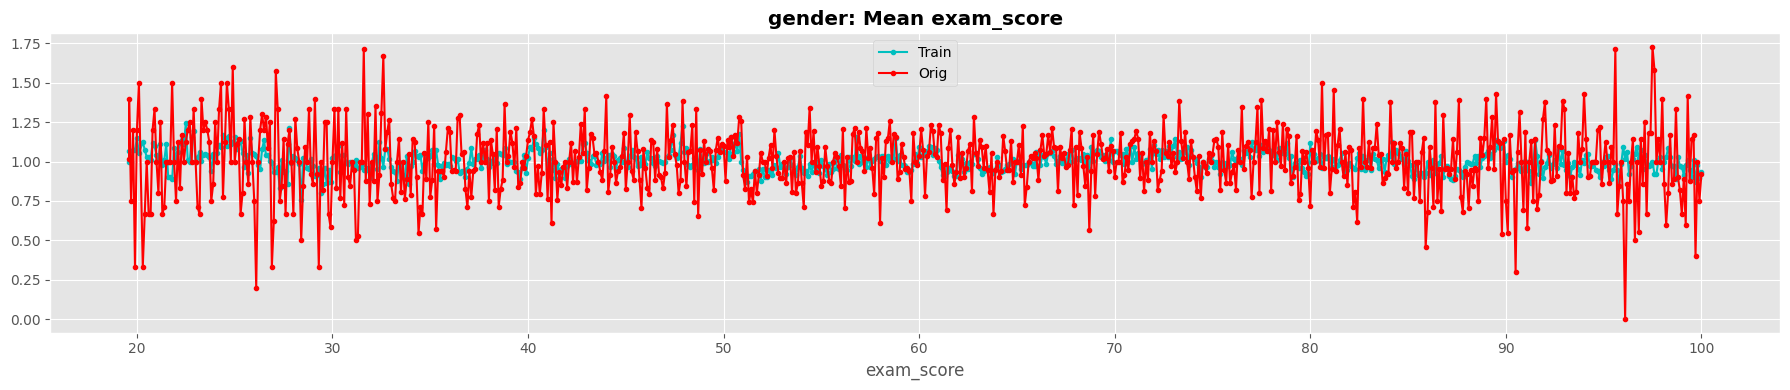

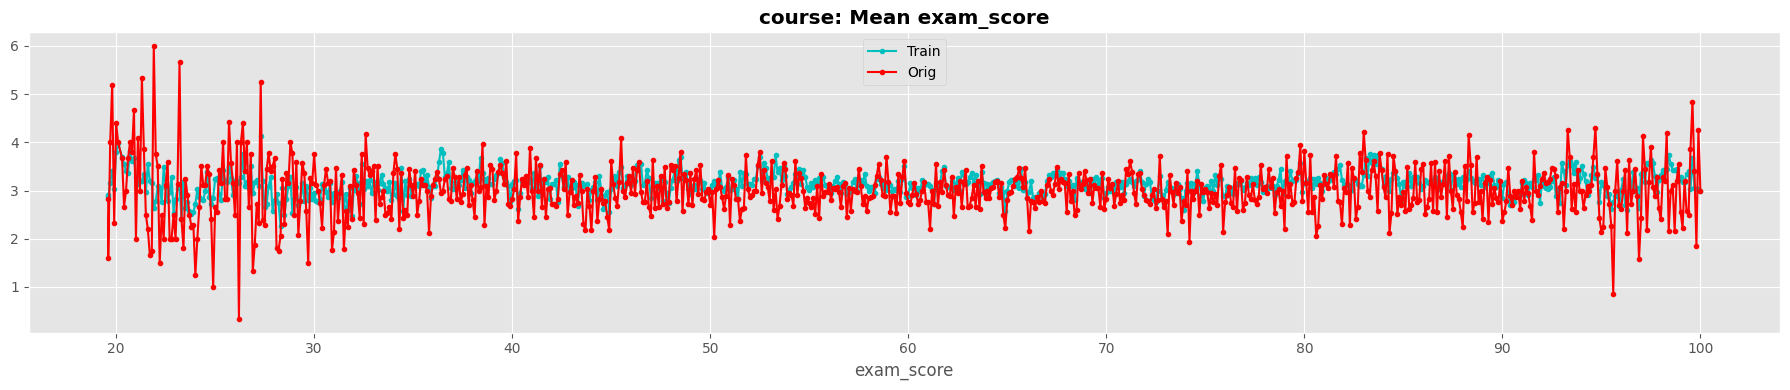

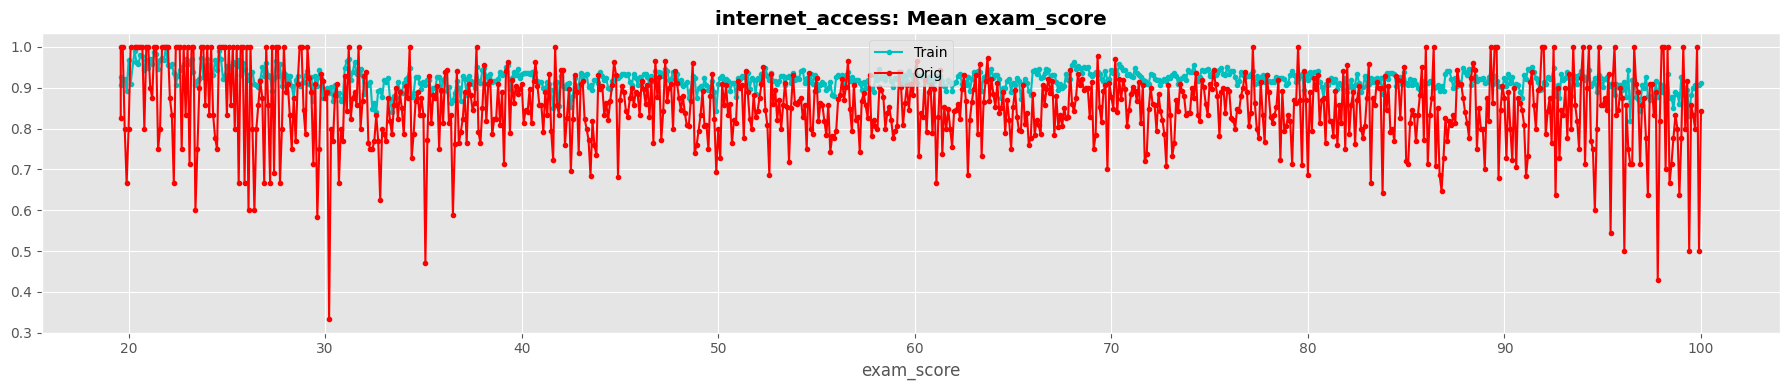

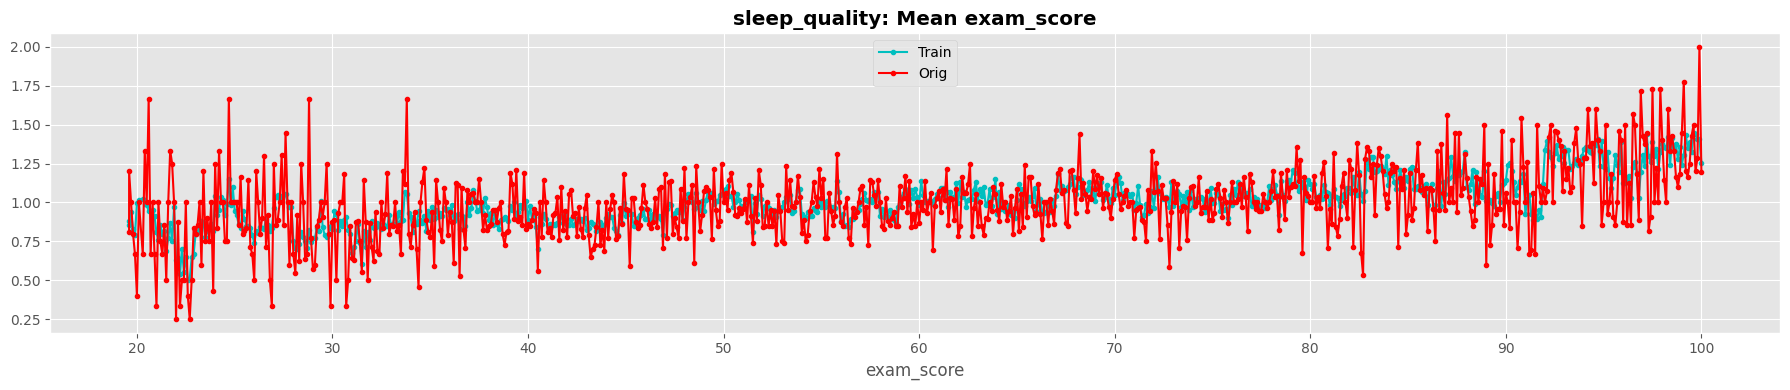

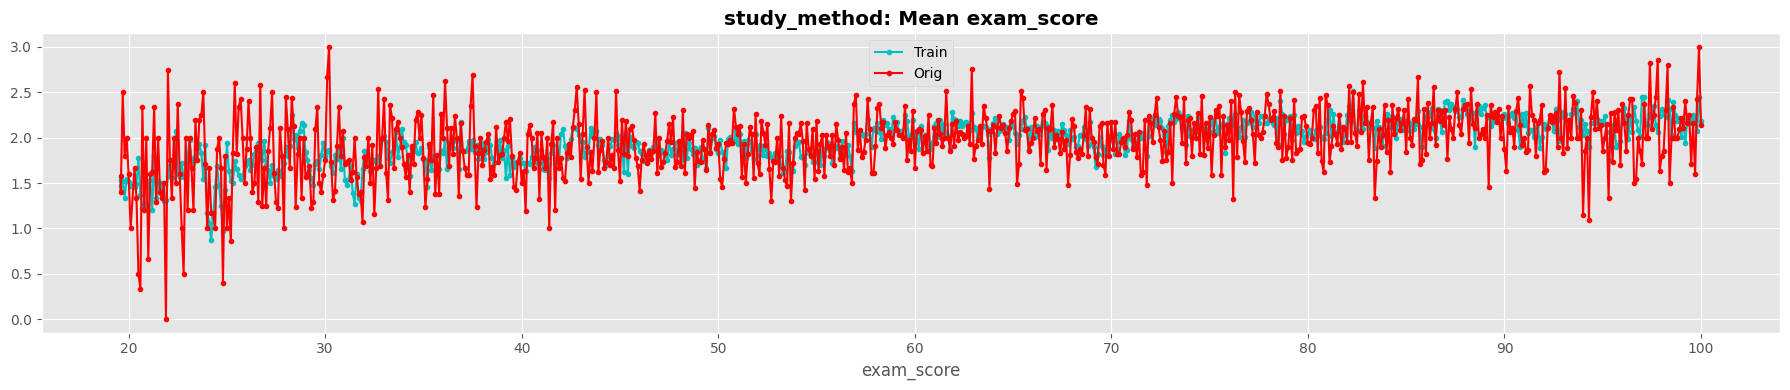

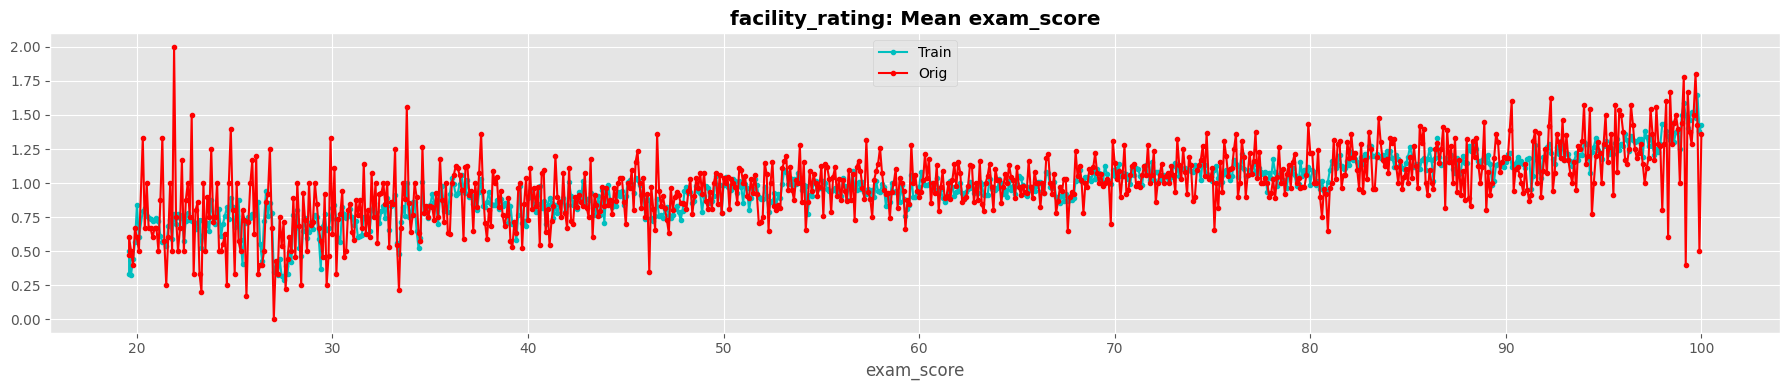

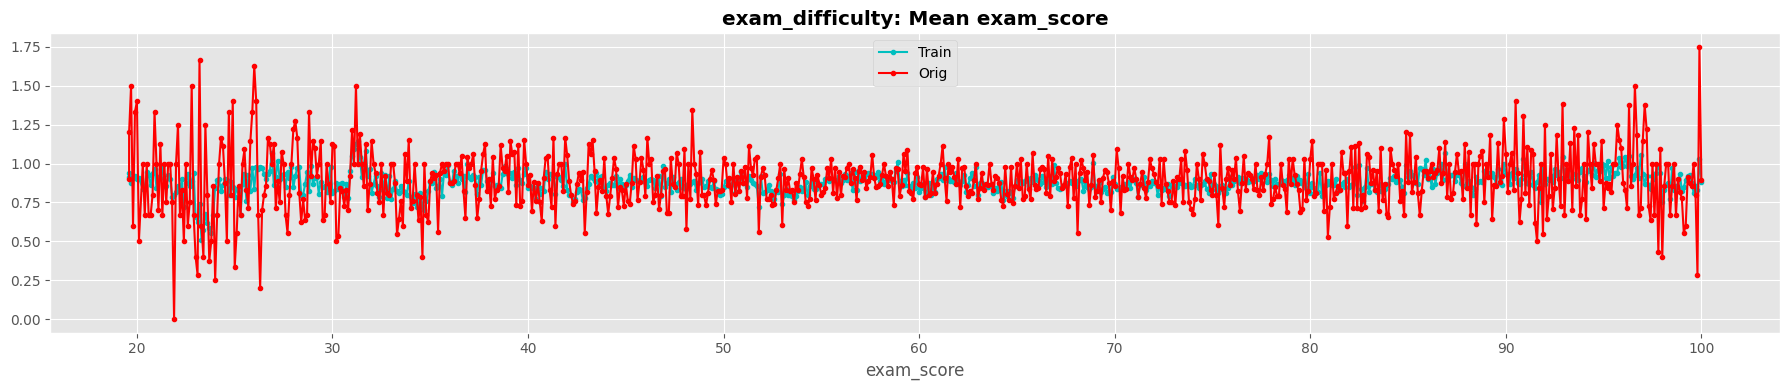

In [28]:
## -- Train/Original relationship: Average target by category --
for i, col in enumerate(BASE):
    plt.figure(figsize=(18, 4))
    df = (train.groupby(TARGET)[col].mean())
    df1 = (orig.groupby(TARGET)[col].mean())
    ax = df.plot(marker='.', color='c', label='Train')
    df1.plot(ax=ax, marker='.', color='r', label='Orig')
    ax.set_title(f"{col}: Mean {TARGET}", fontweight='bold')
    ax.legend(loc='upper center')
    plt.tight_layout()
    
plt.show()

In [29]:
train.corr('spearman')

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
age,1.000000,-0.002305,-0.000342,0.007805,0.005576,-0.001486,0.005943,0.003003,0.008122,0.009141,0.005300,0.007163
gender,-0.002305,1.000000,-0.010303,0.003815,-0.006720,0.002290,-0.015364,-0.014661,-0.002771,-0.004897,-0.005449,-0.006120
course,-0.000342,-0.010303,1.000000,-0.001168,0.013999,0.001040,-0.007471,-0.002086,0.008370,0.005778,0.009156,0.004047
study_hours,0.007805,0.003815,-0.001168,1.000000,0.087262,-0.005389,0.042778,0.027220,0.029190,0.030607,0.012841,0.769757
class_attendance,0.005576,-0.006720,0.013999,0.087262,1.000000,0.016402,0.028739,0.001299,0.017379,0.030107,-0.000777,0.351515
internet_access,-0.001486,0.002290,0.001040,-0.005389,0.016402,1.000000,-0.008570,0.001952,-0.011917,-0.001733,-0.000411,0.002793
sleep_hours,0.005943,-0.015364,-0.007471,0.042778,0.028739,-0.008570,1.000000,0.009849,0.017333,-0.000947,-0.006824,0.160048
sleep_quality,0.003003,-0.014661,-0.002086,0.027220,0.001299,0.001952,0.009849,1.000000,0.003691,0.006043,0.001247,0.113328
study_method,0.008122,-0.002771,0.008370,0.029190,0.017379,-0.011917,0.017333,0.003691,1.000000,0.006804,0.014810,0.101591
facility_rating,0.009141,-0.004897,0.005778,0.030607,0.030107,-0.001733,-0.000947,0.006043,0.006804,1.000000,-0.002518,0.180567


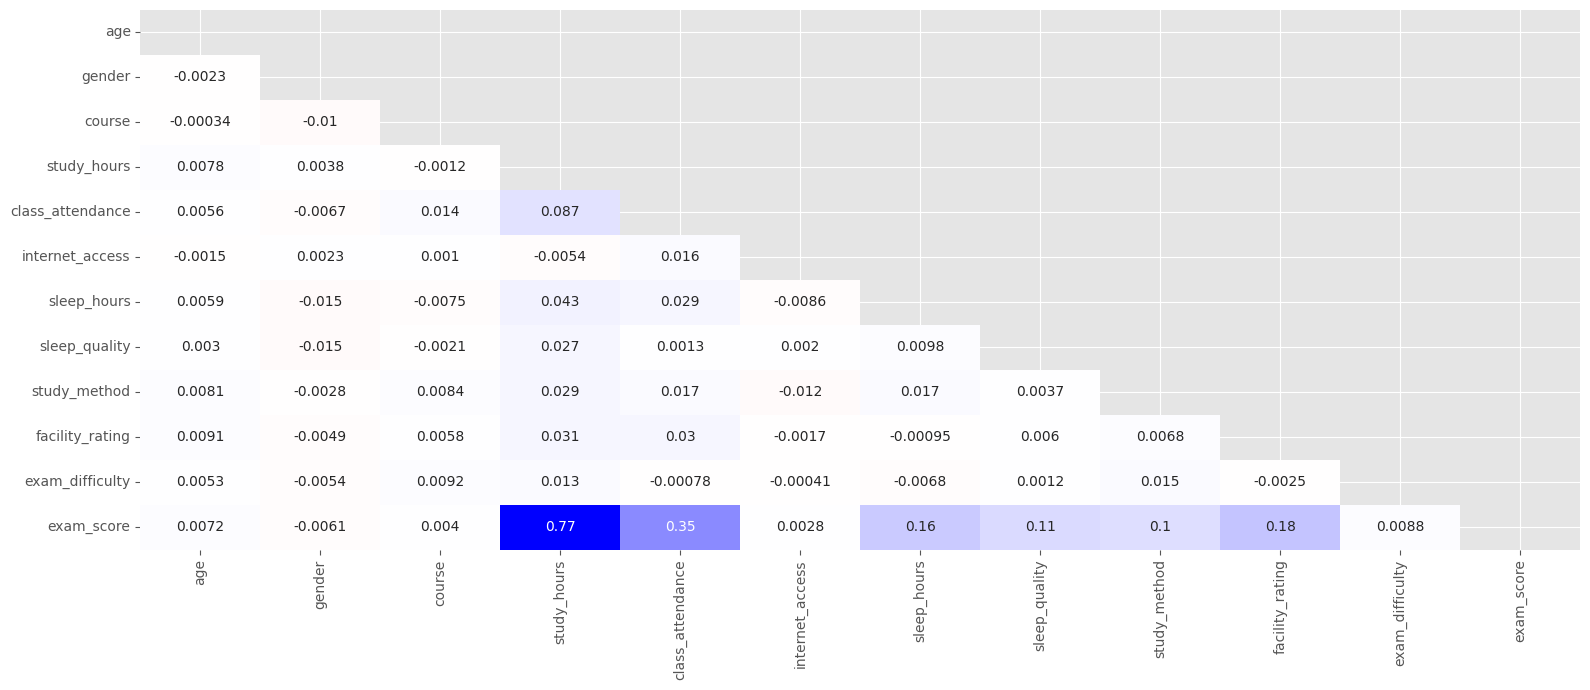

In [30]:
## -- Correlation (SpearmanRho) Heatmap --
CORR = train.corr('spearman')
plt.figure(figsize=(16, 7))
sns.heatmap(CORR, mask=np.triu(CORR), annot=True, cbar=False, cmap='bwr_r', center=0)
plt.tight_layout()
plt.show()

In [31]:
# %%time
# ## -- Mutual Info: Features vs Target --
# mutual_info = mutual_info_regression(train[BASE], train[TARGET])
# mutual_info_df = pd.DataFrame.from_dict(
#                         dict(zip(test.columns.tolist(), list(mutual_info))),
#                         orient='index', columns=['Score'],
# ).sort_values(by='Score', ascending=False)

# # plt.figure(figsize=(18, 6))
# sns.barplot(data=mutual_info_df, x='Score', y=mutual_info_df.index)
# plt.title("-- Univariate Analysis: Top predictors --")
# plt.show()

## 1. Kolmogorov-Smirnov (K-S) test

feature             	ks-stat   	drift
-------             	-------   	-----
age                 	0.0008    	✅ Safe!
study_hours         	0.0015    	✅ Safe!
class_attendance    	0.0013    	✅ Safe!
sleep_hours         	0.0009    	✅ Safe!
gender              	0.0016    	✅ Safe!


course              	0.0008    	✅ Safe!
internet_access     	0.0013    	✅ Safe!
sleep_quality       	0.002     	✅ Safe!
study_method        	0.001     	✅ Safe!
facility_rating     	0.0014    	✅ Safe!
exam_difficulty     	0.0003    	✅ Safe!


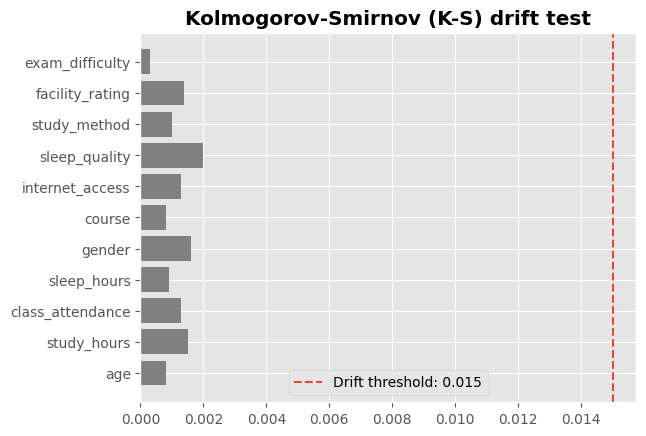

In [32]:
from scipy.stats import ks_2samp

def k_s_drift_test(train, test):
    df_train = train.copy()
    df_test  = test.copy()

    ks_stats_all = []
    cols = []
    threshold = 0.015

    print(f"{'feature':<20}\t{'ks-stat':<10}\t{'drift'}")
    print(f"{'-------':<20}\t{'-------':<10}\t{'-----'}")
    
    for c in BASE:
        ks_stat, p_val = np.round(ks_2samp(df_train[c].values, df_test[c].values), 4)
        if ks_stat >= threshold:
            print(f"{COLOR}{c:<20}\t{ks_stat:<10}\t❌ Drift{RESET}")
        else:
            print(f"{c:<20}\t{ks_stat:<10}\t✅ Safe!")

        ks_stats_all.append(ks_stat)
        cols.append(c)

    plt.barh(cols, ks_stats_all, color=['r' if c >= threshold else 'gray'for c in ks_stats_all])
    plt.axvline(x=threshold, linestyle='--', label=f'Drift threshold: {threshold}') #, xmin=0, xmax=1
    plt.title('Kolmogorov-Smirnov (K-S) drift test', fontweight='semibold')
    plt.legend()
    plt.show()

    gc.collect()

## -- Execute function --
k_s_drift_test(train, test)

## 2. DeepChecks (TrainTestFeatureDrift) test

Link: [Website](https://deepchecks.readthedocs.io/en/0.4.0/examples/checks/distribution/train_test_feature_drift.html)

In [33]:
# try:
#     from deepchecks.tabular import Dataset
#     from deepchecks.tabular.checks import FeatureDrift
# except:
#     !pip install -qq -U deepchecks
#     from deepchecks.tabular import Dataset
#     from deepchecks.tabular.checks import FeatureDrift

# ## -- Prepare dataset for DC --
# train_dataset = Dataset(train[BASE], cat_features=CATS)
# test_dataset = Dataset(test[BASE], cat_features=CATS)

# ## -- Create/Fit model --
# model = xgb.XGBRegressor(random_state=SEED)
# model.fit(train[BASE], train[TARGET])

# check = FeatureDrift()
# result = check.run(train_dataset=train_dataset, test_dataset=test_dataset, model=model)
# result.show()

# drift_test_df = pd.DataFrame()
# for k, v in result.value.items():
#     drift_test_df = pd.concat([drift_test_df, pd.DataFrame({k: v})], axis=1, copy=False)

# drift_test_df.T.sort_values(by=['Drift score'], ascending=False)\
#     .style.background_gradient(subset=['Drift score', 'Importance'], cmap='plasma')

## 3. Evidently (DataDriftTable) test

Link: [Website](https://deepchecks.readthedocs.io/en/0.4.0/examples/checks/distribution/train_test_feature_drift.html)

In [34]:
# try:
#     from evidently import Dataset
#     from evidently import DataDefinition
#     from evidently import Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset 
# except:
#     !pip install -qq -U evidently
#     from evidently import Dataset
#     from evidently import DataDefinition
#     from evidently import Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset

# schema = DataDefinition(numerical_columns=NUMS, categorical_columns=CATS)

# train_df = Dataset.from_pandas(train[BASE], data_definition=schema)
# test_df = Dataset.from_pandas(test[BASE], data_definition=schema)

# report = Report([DataDriftPreset()])
# my_eval = report.run(train_df, test_df)
# my_eval

# FEATURE ENGINEERING

In [35]:
## -- Define categories for OHE --
CAT_COLS = [c for c in BASE if train[c].dtype=='object' or train[c].nunique() <= 0.01*len(train)]
print(f"ℹ️ Features for OHE: {len(CAT_COLS)} -> {CAT_COLS}")

ℹ️ Features for OHE: 11 -> ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


In [36]:
## -- Reduce data memory --
def reduce_memory(df):
    old_size = sys.getsizeof(df) / (1024*1024)
    for c in tqdm(df.columns, desc='Reducing memory...'):
        # Downcast Integer type
        if df[c].dtype == np.int64: 
            if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
                df[c] = df[c].astype(np.int32)
                # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
                #     df[c] = df[c].astype(np.int16)
                #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
                #         df[c] = df[c].astype(np.int8)
        # Downcast Float type
        elif df[c].dtype == np.float64: 
            if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
                df[c] = df[c].astype(np.float32)
                # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
                #     df[c] = df[c].astype(np.float16)

    new_size = sys.getsizeof(df) / (1024*1024)
    print(f"Size before process: {old_size:.1f}MB")
    print(f"Size after process : {new_size:.1f}MB\n")
    
    return df

train = reduce_memory(train)
test = reduce_memory(test)
orig = reduce_memory(orig)

gc.collect()

print(f"Dataset size reduced!")

Reducing memory...:   0%|          | 0/12 [00:00<?, ?it/s]

Size before process: 62.5MB
Size after process : 33.6MB



Reducing memory...:   0%|          | 0/11 [00:00<?, ?it/s]

Size before process: 24.7MB
Size after process : 13.4MB



Reducing memory...:   0%|          | 0/12 [00:00<?, ?it/s]

Size before process: 2.0MB
Size after process : 1.1MB

Dataset size reduced!


# ML TRAINING

In [37]:
## -- Define Models --
tree_models = {
    'xgb': xgb.XGBRegressor(
        #grow_policy='lossguide',
        # learning_rate = 0.1,
        eval_metric = 'rmse',
        random_state = SEED,
        verbosity = 0,
        enable_categorical = True,
        n_jobs = os.cpu_count(),
        device = 'cuda' if torch.cuda.is_available() else 'cpu',
    ),
    'lgb': lgb.LGBMRegressor(
        #grow_policy='lossguide',
        # learning_rate = 0.1,
        metric = 'rmse',
        random_state = SEED,
        verbose = -1,
        n_jobs = os.cpu_count(),
        device = 'gpu' if torch.cuda.is_available() else 'cpu',
    ),
    'cat': cgb.CatBoostRegressor(
        #grow_policy='SymmetricTree',
        # n_estimators = 100,
        # l2_leaf_reg = 0,
        # learning_rate = 0.1,
        eval_metric = 'RMSE',
        random_state = SEED,
        allow_writing_files = False,
        cat_features = CATS,
        verbose = 0,
        thread_count = os.cpu_count(),
        task_type = 'GPU' if torch.cuda.is_available() else 'CPU',
    ),
    'rf': RandomForestRegressor(
        # n_estimators=20,
        # max_depth=5,
        n_jobs=os.cpu_count(),
        random_state=SEED
    ),
}

print(f"Tree Models to train: {len(tree_models)} -> ", end="")
print(list(tree_models.keys()))

Tree Models to train: 4 -> ['xgb', 'lgb', 'cat', 'rf']


In [38]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
    
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

X = train[FEATURES]
y = train[TARGET].values
y_min, y_max = np.min(y), np.max(y)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_final = pd.DataFrame()
test_final = pd.DataFrame()
model_score = pd.Series()

train.info()

Total Features: 11
<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int32  
 1   gender            630000 non-null  int32  
 2   course            630000 non-null  int32  
 3   study_hours       630000 non-null  float32
 4   class_attendance  630000 non-null  float32
 5   internet_access   630000 non-null  int32  
 6   sleep_hours       630000 non-null  float32
 7   sleep_quality     630000 non-null  int32  
 8   study_method      630000 non-null  int32  
 9   facility_rating   630000 non-null  int32  
 10  exam_difficulty   630000 non-null  int32  
 11  exam_score        630000 non-null  float32
dtypes: float32(4), int32(8)
memory usage: 33.6 MB


Training Models.:   0%|          | 0/4 [00:00<?, ?it/s]


[1] xgb ████████████████████████████████████████


	Fold 1 RMSE: 8.80467


	Fold 2 RMSE: 8.81149


	Fold 3 RMSE: 8.80436


	Fold 4 RMSE: 8.82344


	Fold 5 RMSE: 8.83694
|----------------------------------------------------
| OOF RMSE: 8.81619
| AVG RMSE: 8.81618 ± 0.01247
| Duration: 3.70 secs


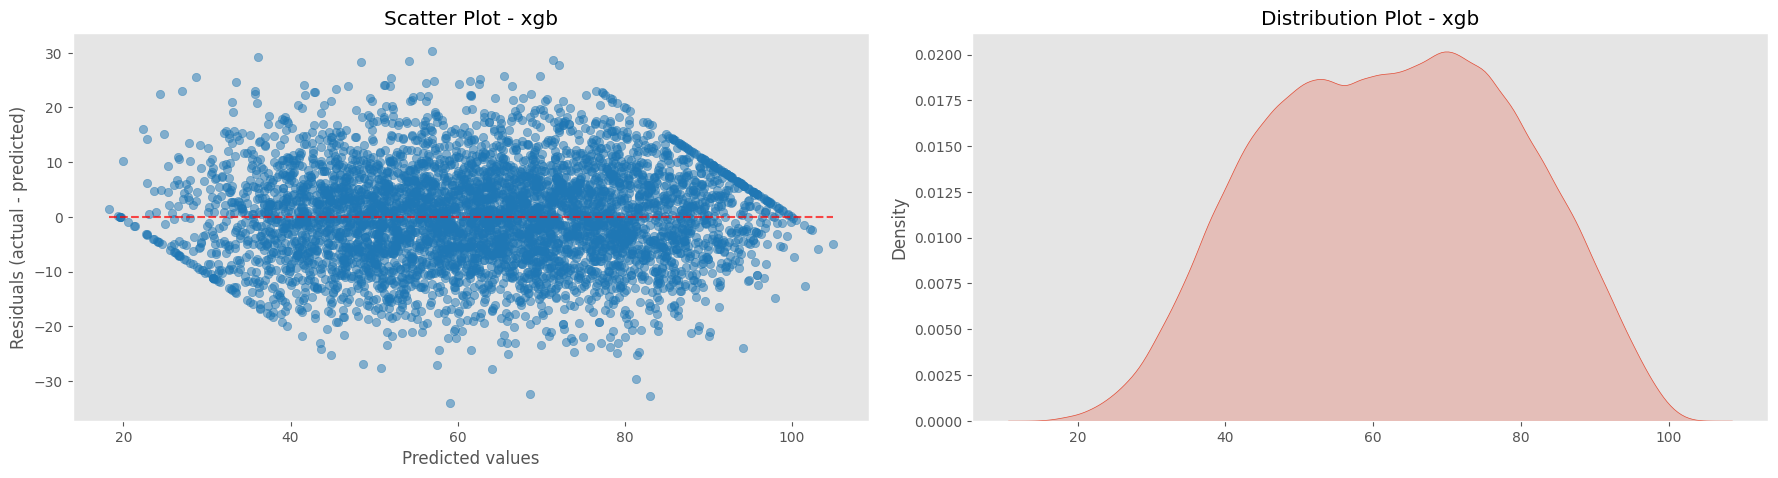


[2] lgb ████████████████████████████████████████


	Fold 1 RMSE: 8.79701


	Fold 2 RMSE: 8.80749


	Fold 3 RMSE: 8.79806


	Fold 4 RMSE: 8.81559


	Fold 5 RMSE: 8.83476
|----------------------------------------------------
| OOF RMSE: 8.81059
| AVG RMSE: 8.81058 ± 0.01386
| Duration: 131.88 secs


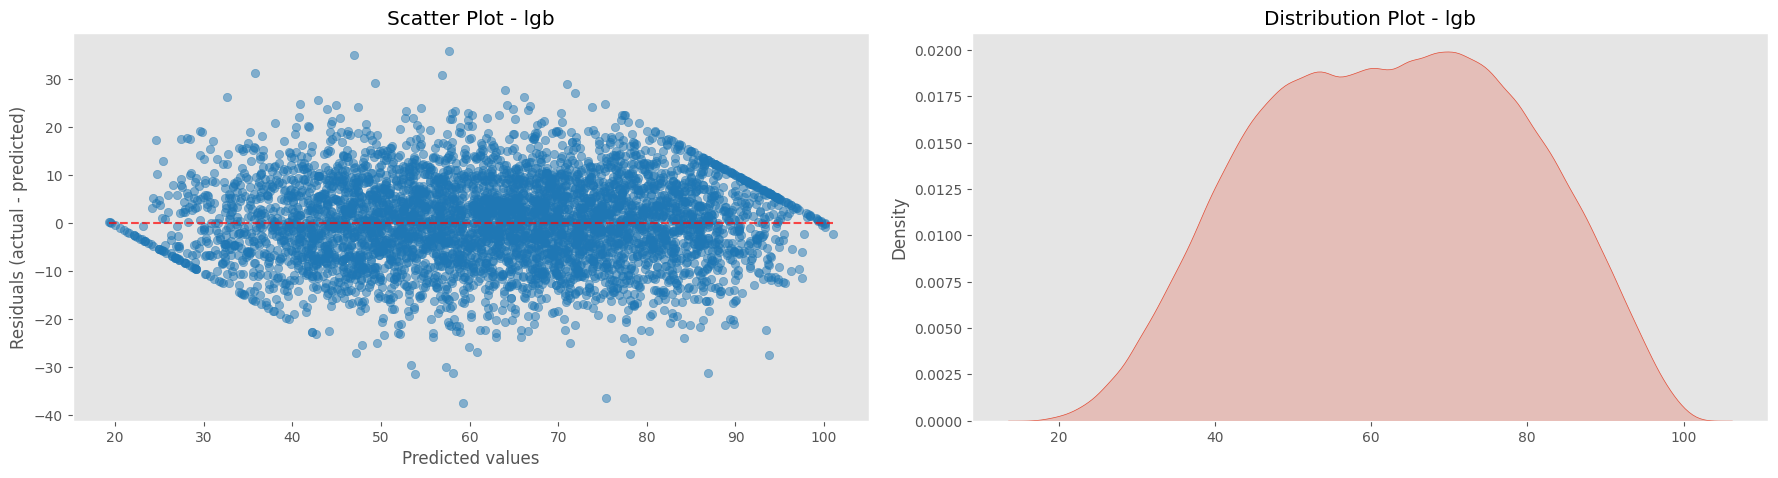


[3] cat ████████████████████████████████████████


	Fold 1 RMSE: 8.75467


	Fold 2 RMSE: 8.76080


	Fold 3 RMSE: 8.75029


	Fold 4 RMSE: 8.76974


	Fold 5 RMSE: 8.78437
|----------------------------------------------------
| OOF RMSE: 8.76398
| AVG RMSE: 8.76397 ± 0.01211
| Duration: 338.81 secs


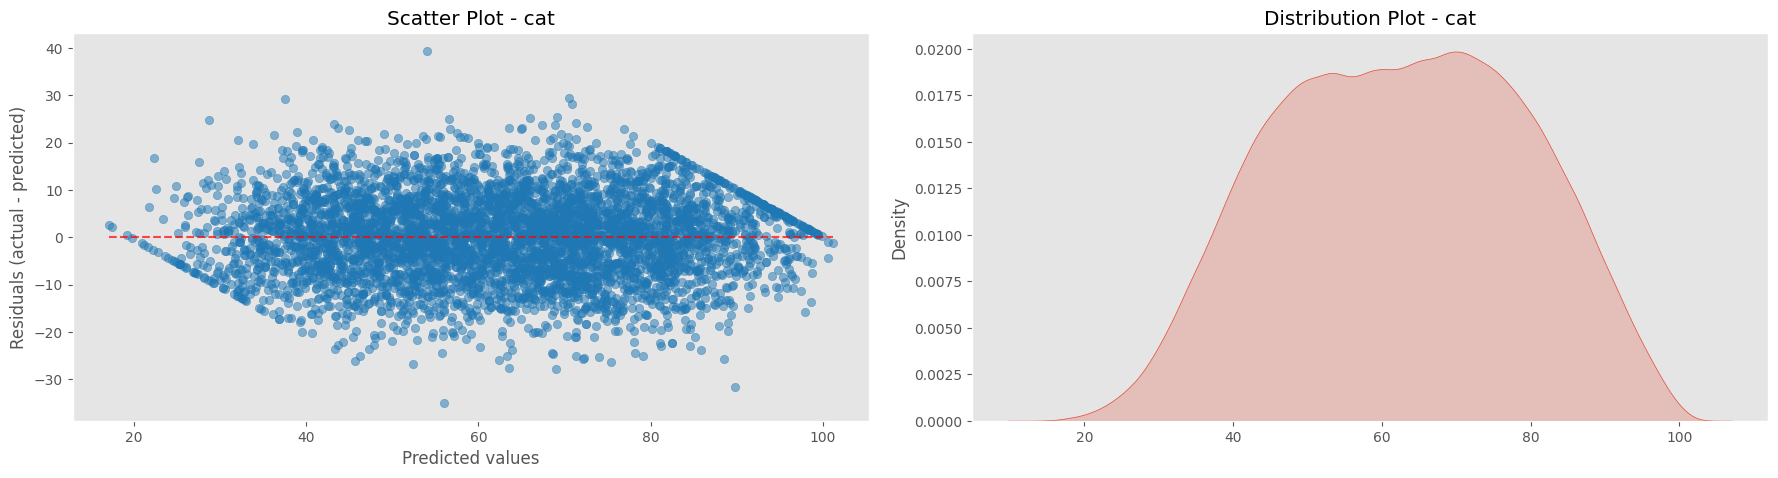


[4] rf ████████████████████████████████████████


	Fold 1 RMSE: 9.12254


	Fold 2 RMSE: 9.13281


	Fold 3 RMSE: 9.12386


	Fold 4 RMSE: 9.12444


	Fold 5 RMSE: 9.15657
|----------------------------------------------------
| OOF RMSE: 9.13206
| AVG RMSE: 9.13205 ± 0.01278
| Duration: 25.95 secs


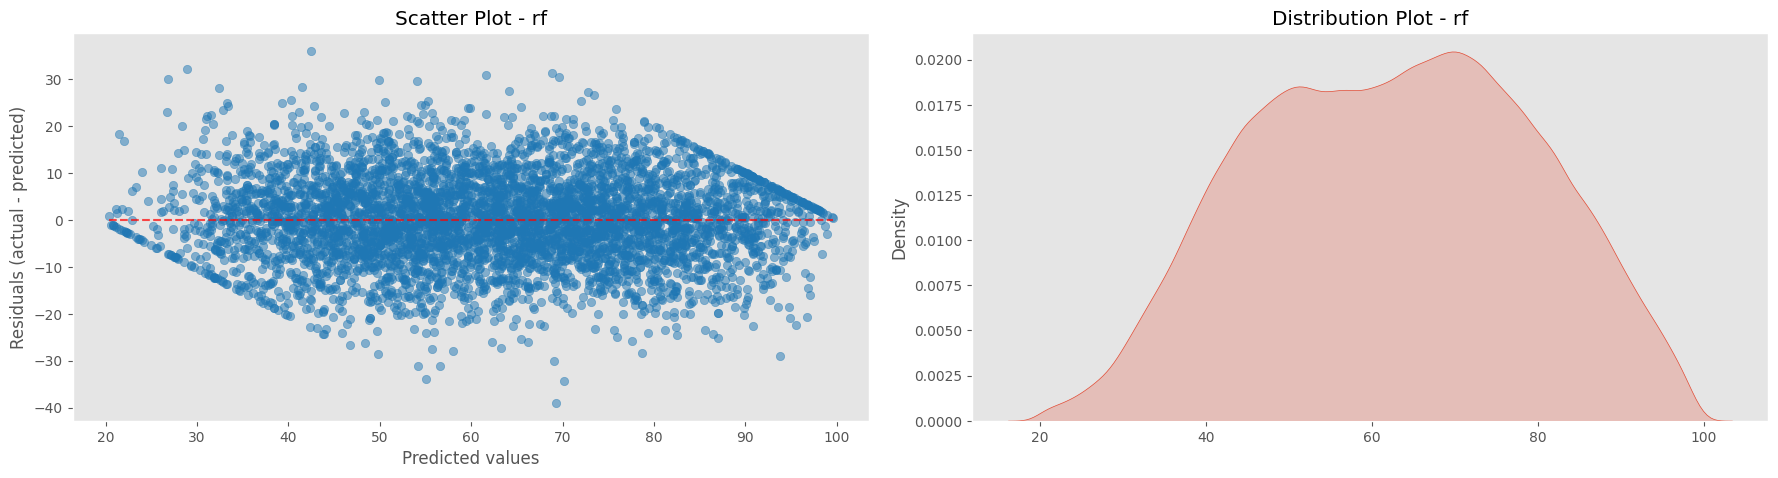

In [39]:
## -- Initiate Training -- 

TREE_MODELS = {}

for i, (name, model) in tqdm(
    enumerate(tree_models.items()),
    total=len(tree_models),
    desc='Training Models.'
):
    print(f"\n[{i+1}] {COLOR}{name} {'█'*40}{RESET}")
    tik = time()

    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(test))
    fold_RMSEs = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        X_test = test[FEATURES].copy()

        ## -- Concatenate original data --
        X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        for c in CATS:
            X_train[c] = X_train[c].astype('category')
            X_val[c]   = pd.Categorical(X_val[c], categories=X_train[c].cat.categories)
            X_test[c]  = pd.Categorical(X_test[c], categories=X_train[c].cat.categories)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        oof_preds[val_idx] = y_pred

        ## -- Compute and save RMSE for val fold --
        fold_rmse = rmse(y_val, y_pred)
        fold_RMSEs.append(fold_rmse)

        ## -- Predict on test set --
        predictions = model.predict(X_test)
        test_preds += predictions / kf.n_splits

        print(f"\tFold {fold+1} RMSE: {fold_rmse:.5f}")

    tok = time()
    tiktok = tok-tik

    ## -- After all folds --
    oof_final[name] = oof_preds
    test_final[name] = test_preds
    TREE_MODELS[name] = model
    
    overall_RMSE = np.round(rmse(y, oof_preds), 5)
    model_score[name] = overall_RMSE
    
    print(f"|{'-'*52}")
    print(f"| OOF RMSE: {overall_RMSE}")
    print(f"| AVG RMSE: {np.mean(fold_RMSEs):.5f} ± {np.std(fold_RMSEs):.5f}")
    print(f"| Duration: {tiktok:.2f} secs")
    
    ## -- Plot residuals --
    fig, axs = plt.subplots(1, 2, figsize=(18, 5))
    display = PredictionErrorDisplay.from_predictions(
        y, oof_preds, subsample=5000, ax=axs[0],
        # kind="actual_vs_predicted",
        scatter_kwargs={'alpha': 0.5},
        line_kwargs={'color': 'r'},
    )
    axs[0].set_title(f"Scatter Plot - {name}")
    ## -----------------------------------------------------
    sns.kdeplot(oof_preds, fill=True, ax=axs[1])
    axs[1].set_title(f"Distribution Plot - {name}") 
    ## -----------------------------------------------------
    for ax in axs: ax.grid(False)
    fig.tight_layout(pad=1.5) 
    plt.show()

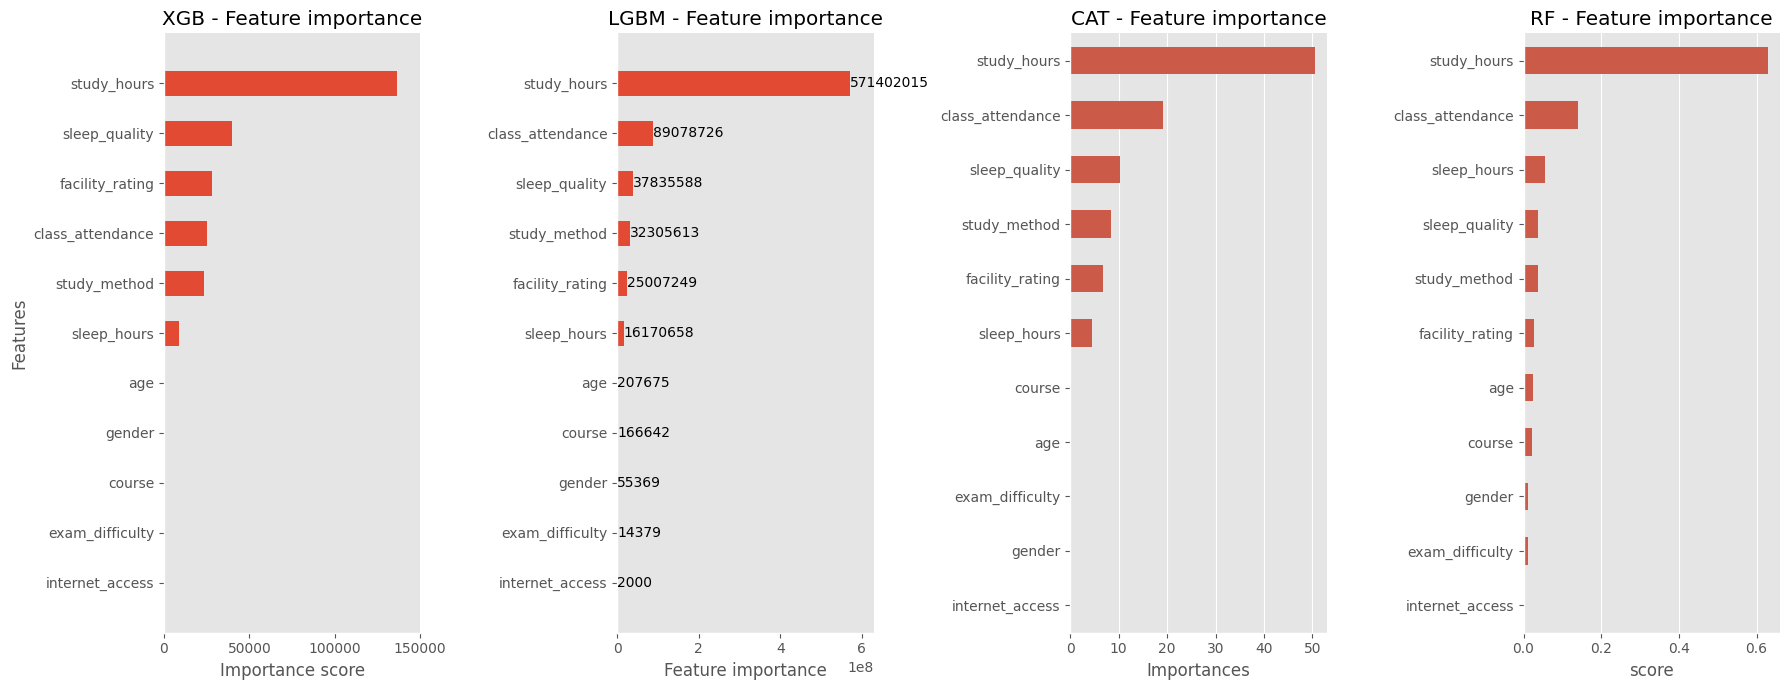

In [40]:
## -- Plot Feature Importances -- 
fig, axs = plt.subplots(1, 4, figsize=(18, 7))

## -- XGBoost --
xgb.plot_importance(
    TREE_MODELS['xgb'],
    importance_type='gain',
    title='XGB - Feature importance',
    grid=False,
    height=0.5,
    show_values=False,
    ax=axs[0],
)

## -- LightGBM -- 
lgb.plot_importance(
    TREE_MODELS['lgb'],
    importance_type='gain',
    title='LGBM - Feature importance',
    ax=axs[1],
    grid=False,
    height=0.5,
    precision=0,
)
axs[1].set_ylabel('')

## -- CatBoost -- 
cat_imp_df = TREE_MODELS['cat'].get_feature_importance(prettified=True)
sns.barplot(data=cat_imp_df, x='Importances', y='Feature Id', width=0.5, ax=axs[2])
axs[2].set_title('CAT - Feature importance')
axs[2].set_ylabel('')

## -- RandomForest -- 
rf_dicts = dict(zip(X_train.columns, TREE_MODELS['rf'].feature_importances_))
rf_imp_df = pd.DataFrame.from_dict(rf_dicts, orient='index', columns=['score'])\
                        .sort_values('score', ascending=False)
sns.barplot(rf_imp_df, x=rf_imp_df.score, y=rf_imp_df.index, width=0.5, ax=axs[3])
axs[3].set_title('RF - Feature importance')
axs[3].set_ylabel("")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
plt.tight_layout()
plt.show()

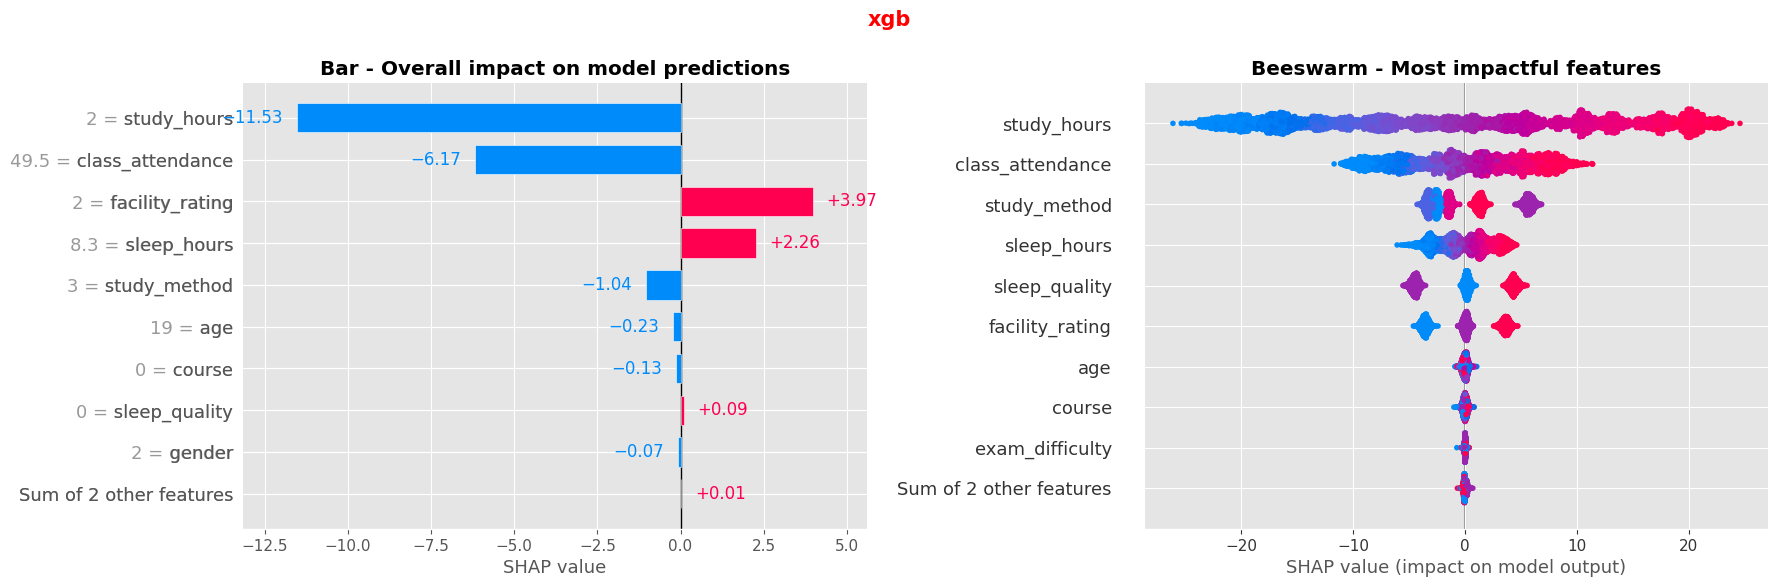

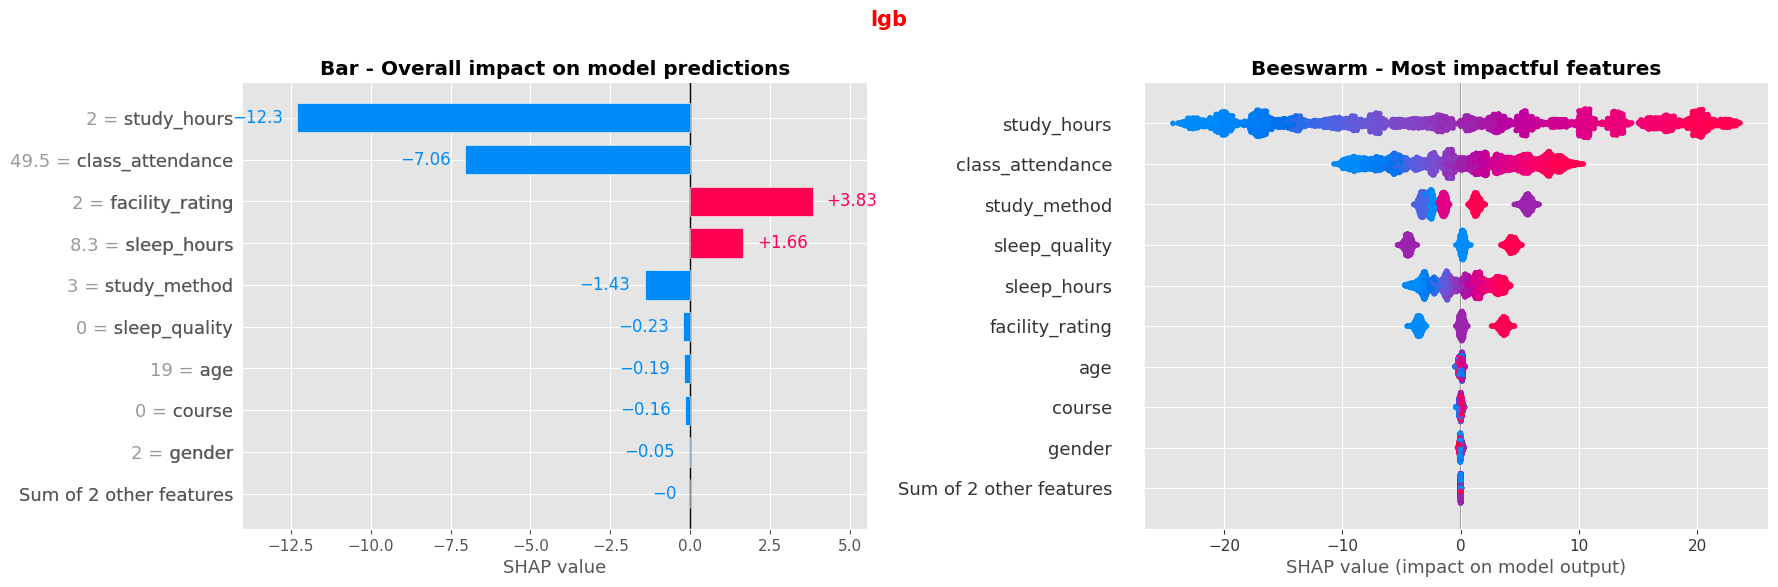

In [41]:
## -- Plot SHAP values --
MAX = 10
for i, (name, model) in enumerate(TREE_MODELS.items()):
    if name in ['xgb', 'lgb']:
        ## -- Shap Explainer --
        explainer = shap.TreeExplainer(model)
        explanation = explainer(X_val.iloc[:5000])

        ## -- Bar plot --
        plt.subplot(121)
        shap.plots.bar(
            explanation[0],
            max_display=MAX,
            show=False
        )
        plt.title('Bar - Overall impact on model predictions', fontweight='semibold')

        ## -- Beeswarm plot --
        plt.subplot(122)
        shap.plots.beeswarm(
            explanation,
            max_display=MAX,
            order=explanation.abs.max(0),
            color_bar=False,
            plot_size=(18.0, 6.0),
            show=False,
        )

        plt.title('Beeswarm - Most impactful features', fontweight='semibold')
        plt.suptitle(f"{name}", fontweight='bold', fontsize=15, color='r')
        plt.tight_layout(pad=1.5) 
        plt.show() 
        print()

In [42]:
oof_final.head(3), test_final.head(3)

(         xgb        lgb        cat         rf
 0  86.257217  84.187301  86.407737  89.015001
 1  62.628784  64.103664  63.425259  64.484000
 2  74.829155  74.992759  75.085202  78.586000,
          xgb        lgb        cat       rf
 0  72.082339  72.076327  72.259282  69.0566
 1  70.326856  70.113410  69.959993  69.4466
 2  88.853586  87.780204  88.219460  83.2382)

## ~ LINEAR MODELS

In [43]:
from sklearn.linear_model import (
            LinearRegression,
            ElasticNet,
            Lasso,
            Ridge,
            Lars,
            LassoLars,
            BayesianRidge,
            ARDRegression,
            TheilSenRegressor,
            HuberRegressor,
            RANSACRegressor,
            OrthogonalMatchingPursuit,
            QuantileRegressor,
)
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [44]:
## -- Define Models --
linear_models = {
    'lr': LinearRegression(n_jobs=os.cpu_count()),
    'enet': ElasticNet(max_iter=1000, tol=1e-5, random_state=SEED),
    'lasso': Lasso(max_iter=1000, tol=1e-5, random_state=SEED),
    'bayes': BayesianRidge(max_iter=1000, tol=1e-5),
    'lars': Lars(random_state=SEED),
    'lassolars': LassoLars(max_iter=1000, random_state=SEED),
    'ard': ARDRegression(max_iter=1000, tol=1e-5),
    'huber': HuberRegressor(max_iter=1000, alpha=1.0, tol=1e-5),
    'omp': OrthogonalMatchingPursuit(tol=1e-5),
    'tsen': TheilSenRegressor(
        max_iter=1000,
        max_subpopulation=5000.0,
        tol=1e-5,
        random_state=SEED,
        n_jobs=os.cpu_count(),
    ),
    'mlp': MLPRegressor(max_iter=1000, tol=1e-5, random_state=SEED),
    # 'quanreg': QuantileRegressor(solver='highs'),
    # 'ransac': RANSACRegressor(random_state=SEED),
}

print(f"Linear Models to train: {len(linear_models)} -> ", end="")
print(list(linear_models.keys()))

Linear Models to train: 11 -> ['lr', 'enet', 'lasso', 'bayes', 'lars', 'lassolars', 'ard', 'huber', 'omp', 'tsen', 'mlp']


In [45]:
## -- Initiate Training -- 
LINEAR_MODELS = {}

for i, (name, model) in tqdm(
    enumerate(linear_models.items()),
    total=len(linear_models),
    desc='Training Models.'
):
    print(f"\n[{i+1}] {COLOR}{name} {'█'*40}{RESET}")
    tik = time()

    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(test))
    fold_RMSEs = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        X_test = test[FEATURES].copy()

        ## -- Concatenate original data --
        X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- Create pipeline --
        lr_model = make_pipeline(
            make_column_transformer(
                (OneHotEncoder(
                    handle_unknown='ignore',
                    # sparse_output=False,
                    drop='first',
                ), CATS),
                remainder='passthrough',
                n_jobs=os.cpu_count(),
            ),
            StandardScaler(with_mean=False), #with_mean=False
            model,
        )

        lr_model.fit(X, y)
        y_pred = lr_model.predict(X_val)
        oof_preds[val_idx] = y_pred

        # Predict on test set (accumulate final prediction)
        predictions = lr_model.predict(X_test)
        test_preds += predictions / kf.n_splits

        # Compute RMSE for validation fold
        fold_rmse = np.round(rmse(y_val, y_pred), 5)
        fold_RMSEs.append(fold_rmse)

        print(f"\tFold {fold+1} RMSE: {fold_rmse}")

    ## -- After all folds --
    overall_RMSE = np.round(rmse(y, oof_preds), 5)
    print(f"|{'-'*52}")
    print(f"| OOF RMSE: {overall_RMSE}")
    print(f"| AVG RMSE: {np.mean(fold_RMSEs):.5f} ± {np.std(fold_RMSEs):.5f}")
    
    # ## -- Plot residuals --
    # fig, axs = plt.subplots(1, 2, figsize=(18, 5))
    # display = PredictionErrorDisplay.from_predictions(
    #     y,
    #     oof_preds,
    #     subsample=5000,
    #     ax=axs[0],
    #     # kind="actual_vs_predicted",
    #     scatter_kwargs={'alpha': 0.5},
    #     line_kwargs={'color': 'r'},
    # )
    # axs[0].set_title(f"Scatter Plot - {name}")
    # # -----------------------------------------------------
    # sns.kdeplot(oof_preds, fill=True, ax=axs[1])
    # axs[1].set_title(f"Distribution Plot - {name}") 
    # # -----------------------------------------------------
    # for ax in axs: ax.grid(False)
    # fig.tight_layout(pad=1.5) 
    # plt.show()

    oof_final[name] = oof_preds
    test_final[name] = test_preds
    LINEAR_MODELS[name] = lr_model
    model_score[name] = overall_RMSE
    
    tok = time()
    tiktok = tok-tik
    print(f"| Duration: {tiktok:.2f} secs")
    gc.collect()

Training Models.:   0%|          | 0/11 [00:00<?, ?it/s]


[1] lr ████████████████████████████████████████


	Fold 1 RMSE: 8.88488


	Fold 2 RMSE: 8.89001


	Fold 3 RMSE: 8.88346


...

	Fold 1 RMSE: 8.82135


	Fold 2 RMSE: 8.82618


	Fold 3 RMSE: 8.81695


	Fold 4 RMSE: 8.83716


	Fold 5 RMSE: 8.85168
|----------------------------------------------------
| OOF RMSE: 8.83067
| AVG RMSE: 8.83066 ± 0.01248
| Duration: 3138.81 secs


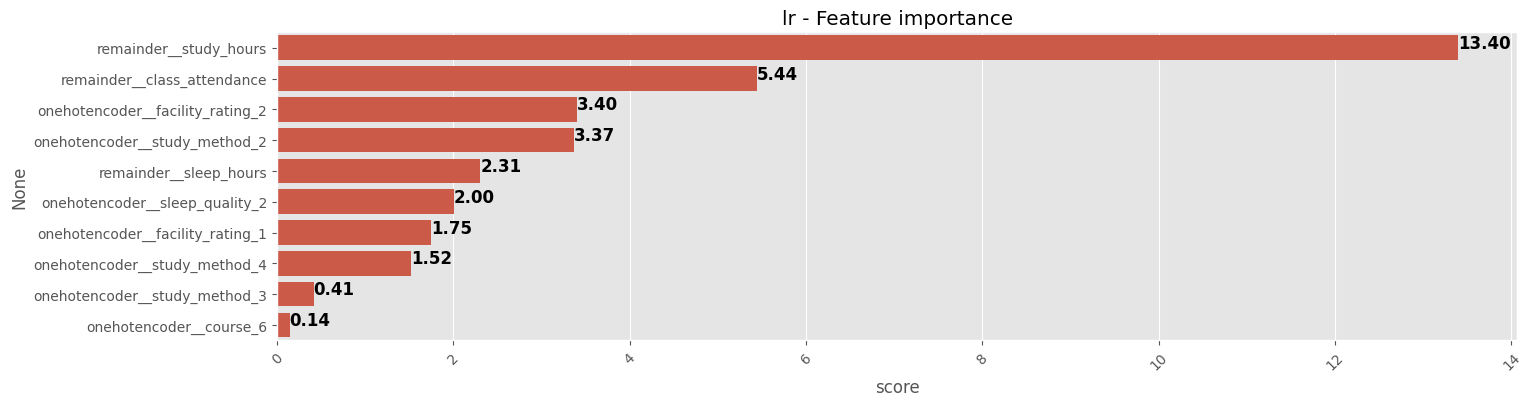

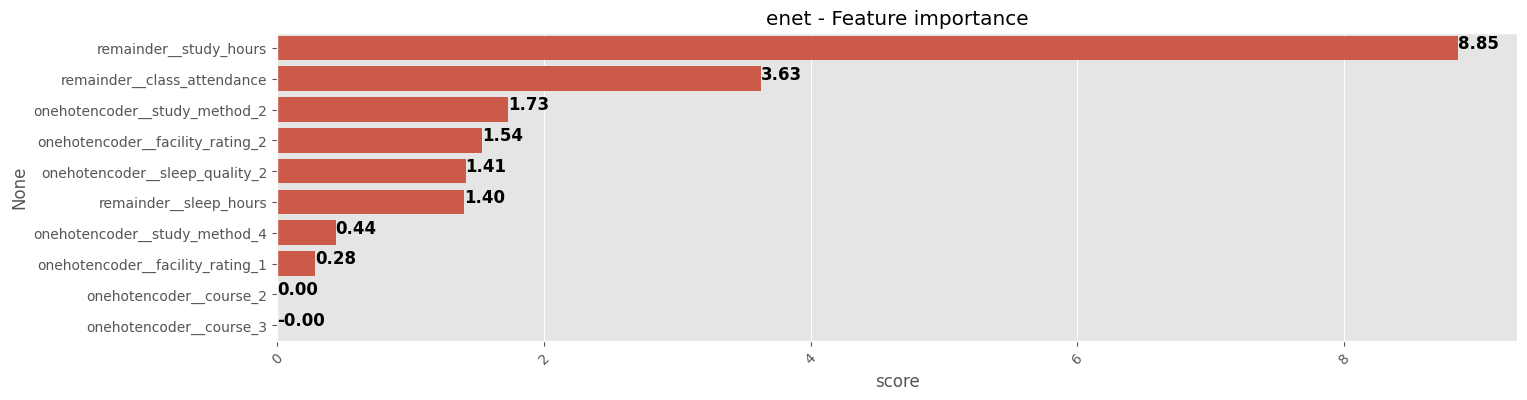

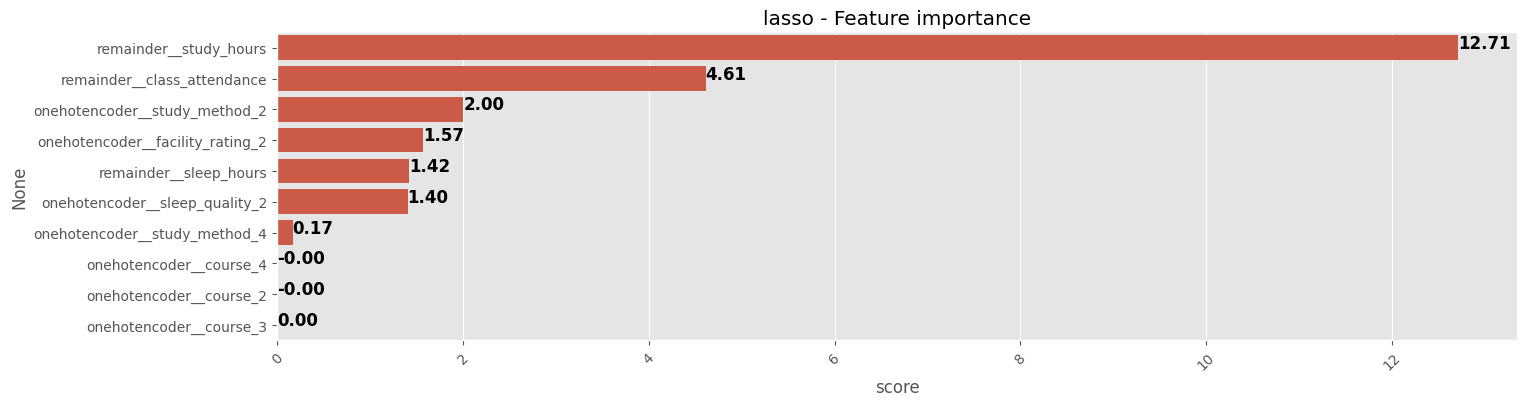

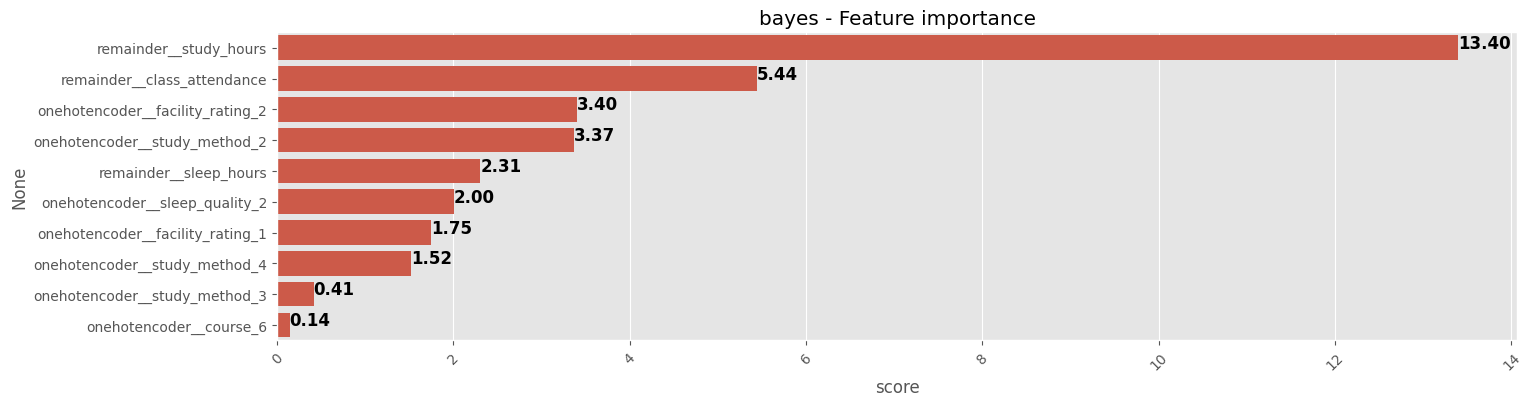

In [46]:
## -- Feature Importances: Linear Model --
for i, name in enumerate(list(LINEAR_MODELS.keys())[:4]):
    coef_dict = dict(
        zip(
            LINEAR_MODELS[name].named_steps['columntransformer'].get_feature_names_out(),
            LINEAR_MODELS[name][-1].coef_
        )
    )
    reg_imp = pd.DataFrame.from_dict(
        coef_dict,
        orient='index',
        columns=['score']
    ).sort_values('score', ascending=False).iloc[:10] # -> Top 10 features
    reg_imp.columns = ['score']
    
    plt.figure(figsize=(16, 4))
    sns.barplot(data=reg_imp, x='score', y=reg_imp.index)
    plt.xticks(rotation=45)
    plt.title(f'{name} - Feature importance')
    for i, t in enumerate(reg_imp['score'].values):
        plt.text(t, i, f'{t:.2f}', fontdict={'size': 12, 'weight': 'bold'})
    
    # plt.tight_layout()
    plt.show()

In [47]:
# X = train[FEATURES]
# y = train[TARGET]

# ## -- Create pipeline --
# lr_model = make_pipeline(
#     make_column_transformer(
#         (OneHotEncoder(
#             handle_unknown='ignore',
#             # sparse_output=False,
#             drop='first',
#         ), CATS),
#         remainder='passthrough',
#         # n_jobs=-1,
#     ),
#     StandardScaler(with_mean=False), #with_mean=False
#     LinearRegression(),
# )
# lr_model.fit(X, y)

# ## -- Linear Model --
# coef_dict = dict(zip(lr_model[0].get_feature_names_out(), lr_model[-1].coef_))
# reg_imp = pd.DataFrame.from_dict(coef_dict, orient='index', columns=['score'])\
#                       .sort_values('score', ascending=False).iloc[:20]
# reg_imp.columns = ['score']

# plt.figure(figsize=(15, 7))
# sns.barplot(data=reg_imp, x='score', y=reg_imp.index)
# plt.title('LinearRegression - Feature importance')
# for i, t in enumerate(reg_imp['score'].values):
#     plt.text(t, i, f'{t:.2f}', fontdict={'size': 12, 'weight': 'bold'})

# # plt.tight_layout()
# plt.show()

# # pd.DataFrame({'id': submit['id'], TARGET: lr_model.predict(test)}).to_csv('submit_lr1.csv', index=False)

## ~ STACKING


- Fold 1/5 -


	Stack RMSE: 8.72673

- Fold 2/5 -


	Stack RMSE: 8.73257

- Fold 3/5 -


	Stack RMSE: 8.72125

- Fold 4/5 -


	Stack RMSE: 8.74399

- Fold 5/5 -


	Stack RMSE: 8.75955
|--------------------------------------------------
| FEATURES: 15
| OOF RMSE: 8.73683
| AVG RMSE: 8.73682 ± 0.01364


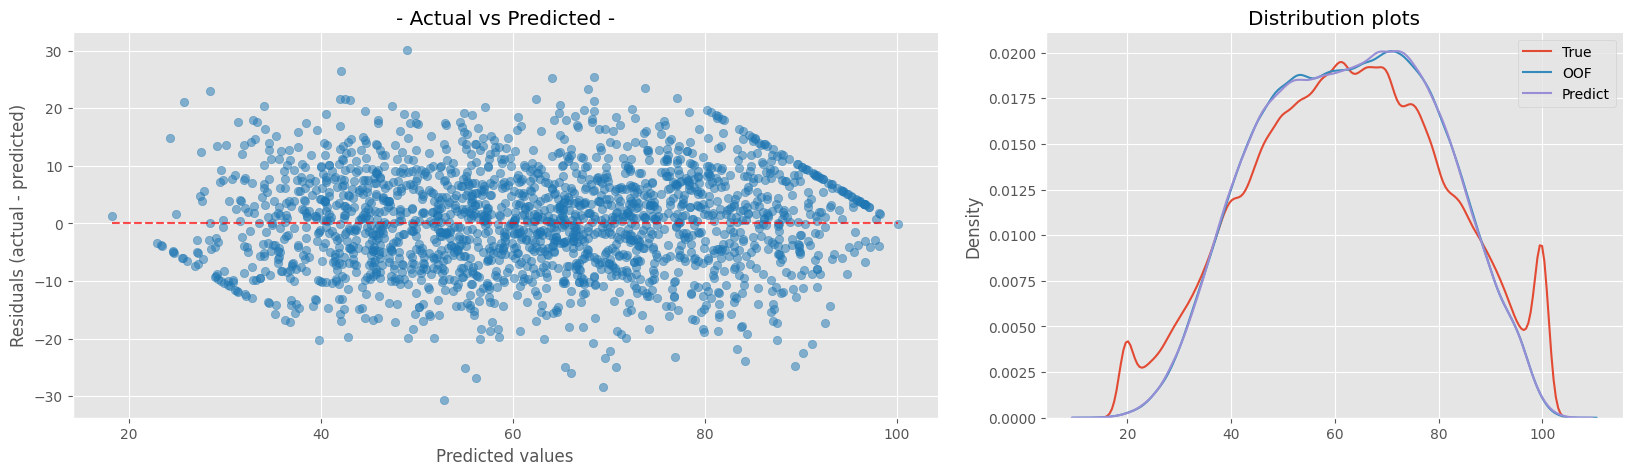

Training Time: 0.10 mins =========================


In [48]:
## -- Define Training Parameters --
stack_oof_preds  = np.zeros(len(oof_final))
stack_test_preds = np.zeros(len(test_final))
fold_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

## -- Split data --
X = oof_final
y = train[TARGET].values

## -- Initiate Training --
tik = time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n- Fold {fold+1}/{kf.n_splits} -")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    X_test = test_final.copy()

    for c in oof_final.columns:
        scaler = StandardScaler()
        X_train[c] = scaler.fit_transform(X_train[[c]], y_train)
        X_val[c]   = scaler.transform(X_val[[c]])
        X_test[c]  = scaler.transform(X_test[[c]])
        
    meta_model = Ridge(tol=1e-5, random_state=SEED).fit(X_train, y_train)
    
    stack_y_pred = meta_model.predict(X_val)
    stack_oof_preds[val_idx] = stack_y_pred
    
    score = np.round(rmse(y_val, stack_y_pred), 5)
    fold_scores.append(score)
    
    predictions = meta_model.predict(X_test)
    stack_test_preds += predictions / kf.n_splits

    print(f"\tStack RMSE: {score}")

## -- After all folds --
stack_score = np.round(rmse(y, stack_oof_preds), 5)
stack_name = 'ridge_stack' + stack_score.astype(str).split('.')[1]

oof_final[stack_name] = stack_oof_preds
test_final[stack_name] = stack_test_preds
model_score[stack_name] = stack_score

print(f"|{'-'*50}{COLOR}")
print(f"| FEATURES: {len(X_train.columns)}")
print(f"| OOF RMSE: {stack_score}")
print(f"| AVG RMSE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}{RESET}")

## -- Plot predictions errors --
_, axs = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios':[0.6, 0.4], 'wspace':0.15})
display = PredictionErrorDisplay.from_predictions(
    y,
    stack_oof_preds,
    ax=axs[0], subsample=2000,
    # kind = "actual_vs_predicted",
    scatter_kwargs={'alpha': 0.5}, line_kwargs={'color': 'r'},
        )
axs[0].set_title(f"- Actual vs Predicted -")

LABELS = ['True', 'OOF', 'Predict']
sns.kdeplot(y, ax=axs[1], label=LABELS[0])
sns.kdeplot(oof_preds, ax=axs[1], label=LABELS[1])
sns.kdeplot(test_preds, ax=axs[1], label=LABELS[2])
axs[1].set_title(f"Distribution plots")

# TEXT = f"""
# True Avg.: {np.mean(y):.5f} | Min: {np.min(y):.2f} | Max: {np.max(y):.2f}
# OOF Avg.: {np.mean(oof_preds):.5f} | Min: {np.min(oof_preds):.2f} | Max: {np.max(oof_preds):.2f}
# Pred Avg.: {np.mean(test_preds):.5f} | Min: {np.min(test_preds):.2f} | Max: {np.max(test_preds):.2f}
#         """
# axs[1].text(x=50, y=0.01, s=TEXT, ha='right', va='top', color='r')

for ax in axs:
    # ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

tok = time()
tiktok = (tok-tik) / 60
print(f"Training Time: {tiktok:.2f} mins {'='*25}")

## ~ HILLCLIMB

In [49]:
try:
    from hillclimbers import climb_hill, partial
except:
    !pip install -q -U hillclimbers
    from hillclimbers import climb_hill, partial


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [50]:
%%time
## -- Run hillclimber --
hc_test_preds, hc_oof_preds = climb_hill(
        train=train,
        target=TARGET,
        oof_pred_df=oof_final.drop([stack_name], axis=1),
        test_pred_df=test_final.drop([stack_name], axis=1),
        eval_metric=partial(rmse),
        objective="minimize",
        precision=0.001,
        negative_weights=True,
        plot_hill=True,
        plot_hist=False,
        return_oof_preds=True
)


   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (15 total): 

cat:       8.76398 (best solo model)
lgb:       8.81059
xgb:       8.81619
mlp:       8.83067
lr:        8.89313
lars:      8.89313
omp:       8.89313
bayes:     8.89313
ard:       8.89315
huber:     8.89442
tsen:      8.91149
rf:        9.13206
lasso:     9.42711
lassolars: 9.42711
enet:      10.69311

[Data preparation completed successfully] - [Initiate hill climbing] 



Iteration: 1 | Model added: xgb | Best weight: 0.237 | Best rmse: 8.75840


Iteration: 2 | Model added: mlp | Best weight: 0.172 | Best rmse: 8.75513


Iteration: 3 | Model added: huber | Best weight: -0.357 | Best rmse: 8.74469


Iteration: 4 | Model added: rf | Best weight: 0.057 | Best rmse: 8.74325


...

Iteration: 8 | Model added: tsen | Best weight: -0.003 | Best rmse: 8.74303


Iteration: 9 | Model added: lars | Best weight: 0.003 | Best rmse: 8.74303


Iteration: 10 | Model added: lasso | Best weight: -0.002 | Best rmse: 8.74303


Iteration: 11 | Model added: bayes | Best weight: 0.002 | Best rmse: 8.74303


CPU times: user 4min 4s, sys: 3.45 s, total: 4min 7s
Wall time: 4min 7s


In [51]:
hc_score = np.round(rmse(y, hc_oof_preds), 5)
hc_name = 'hillclimb'+hc_score.astype(str).split('.')[1]

oof_final[hc_name] = hc_oof_preds
test_final[hc_name] = np.clip(hc_test_preds, y_min, y_max)
model_score[hc_name] = hc_score
model_score.sort_values(inplace=True)
model_score

ridge_stack73683     8.73683
hillclimb74303       8.74303
cat                  8.76398
lgb                  8.81059
xgb                  8.81619
mlp                  8.83067
bayes                8.89313
lars                 8.89313
omp                  8.89313
lr                   8.89313
ard                  8.89315
huber                8.89442
tsen                 8.91149
rf                   9.13206
lassolars            9.42711
lasso                9.42711
enet                10.69311
dtype: float64

In [52]:
oof_final.head(3)

,xgb,lgb,cat,rf,lr,enet,lasso,bayes,lars,lassolars,ard,huber,omp,tsen,mlp,ridge_stack73683,hillclimb74303
0,86.257217,84.187301,86.407737,89.015001,84.109812,79.005144,86.945312,84.109696,84.109812,86.945323,84.158378,84.282172,84.109812,83.549610,85.671159,87.376050,87.228838
1,62.628784,64.103664,63.425259,64.484000,64.590601,62.837498,65.850354,64.590454,64.590601,65.850338,64.576961,64.620904,64.590601,64.738763,65.466909,63.631743,63.300304
2,74.829155,74.992759,75.085202,78.586000,75.810276,70.676947,73.539097,75.810069,75.810276,73.539093,75.814226,75.986753,75.810276,75.251486,76.167456,75.332359,75.192150


In [53]:
test_final.head(3)

,xgb,lgb,cat,rf,lr,enet,lasso,bayes,lars,lassolars,ard,huber,omp,tsen,mlp,ridge_stack73683,hillclimb74303
0,72.082339,72.076327,72.259282,69.0566,71.581870,68.373926,72.560630,71.581632,71.581870,72.560649,71.584893,71.587171,71.581870,71.964402,71.533825,71.850182,72.108132
1,70.326856,70.113410,69.959993,69.4466,69.623927,67.546011,70.824891,69.623811,69.623927,70.824888,69.652893,69.582490,69.623927,69.535563,71.564905,70.940426,70.526835
2,88.853586,87.780204,88.219460,83.2382,87.239605,78.662417,83.835305,87.239246,87.239605,83.835318,87.237891,87.539487,87.239605,87.964306,87.790771,88.110618,88.288293


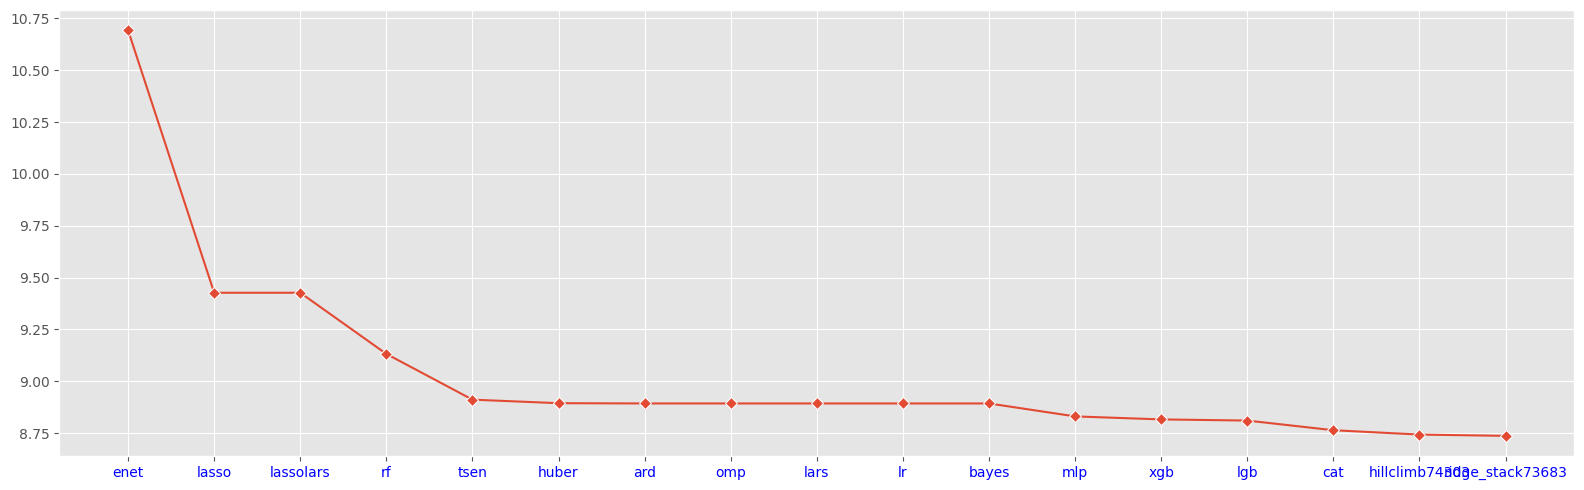

In [54]:
plt.figure(figsize=(16, 5))
sns.lineplot(model_score.sort_values(ascending=False), marker='D')
plt.tick_params(axis='x', labelcolor='b')
plt.tight_layout()
plt.show()

# SUBMISSION

In [55]:
## -- Export OOF & TEST predictions for each model --
n_oof = f'oof_hc-stack_BASE.parquet'
n_pred = f'pred_hc-stack_BASE.parquet'

oof_final.iloc[:, -2:].to_parquet(n_oof, index=False)
test_final.iloc[:, -2:].to_parquet(n_pred, index=False)

print(n_oof, n_pred)

oof_hc-stack_BASE.parquet pred_hc-stack_BASE.parquet


In [56]:
# ## -- Create Submission files --
# for i, c in enumerate(test_final.columns[-2:]):
#     submit[TARGET] = test_final[c].values
#     submit.to_csv(f"submit_{c}_BASE.csv", index=False)
#     print(f" -> submit_{c}_BASE.csv file saved!")